# Best Model

### Installs

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn optuna torch torchvision torchaudio tqdm joblib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 18.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 63.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 35.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 61.8 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 64.0 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Here's a summary of every change made:
FocalLoss class (new) — replaces BCEWithLogitsLoss. Works on raw logits, applies the (1−pt)γ(1-p_t)^\gamma
(1−pt​)γ modulation per sample before averaging. No
pos_weight — focal loss handles easy negatives on its own, and stacking both tends to over-correct at your imbalance ratio.
pos_weight removed throughout — get_pos_weight() is gone, it's no longer passed into run_training, and the print line is replaced with a fraud rate summary which is more informative anyway.
gamma added to Optuna search — trial.suggest_float("gamma", 0.5, 5.0) so the search finds the right focusing strength for your data rather than you having to guess. It's saved in checkpoints and final_metrics.json like any other hyperparameter.
Training curve y-axis label — updated from "BCE Loss" to "Focal Loss" and the config label in the plot title now includes γ=X.XX.
One thing to watch: because focal loss suppresses easy negatives, the raw loss values will be numerically much smaller than BCE, so don't compare loss magnitudes across runs — just track val PR-AUC as before.

In [2]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - FocalLoss (gamma tuned by Optuna, range 0.5–5.0)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal loss for binary classification.

    FL(p_t) = -(1 - p_t)^gamma * log(p_t)

    Works on raw logits (no sigmoid needed before calling).
    pos_weight is dropped vs the old BCE setup — focal loss already
    down-weights easy negatives, so stacking pos_weight on top tends
    to over-correct on heavily imbalanced data.  If you want to keep
    class rebalancing you can re-add it, but start without it and
    check whether val PR-AUC improves.

    Args:
        gamma: focusing parameter. 0.0 → standard BCE.
               Typical range: 0.5–5.0.  Paper default: 2.0.
    """

    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # bce_loss is unreduced so we can apply the focal modulation per-sample
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce)                          # probability of the true class
        focal_weight = (1.0 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(cat, num), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )

    # ── Focal loss — no pos_weight needed ─────────────────────────────────────
    criterion = FocalLoss(gamma=config["gamma"])

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            # ── new: focal loss gamma ─────────────────────────────────────────
            "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    # pos_weight no longer passed — focal loss handles class imbalance
    fraud_rate = train_df[target].mean()
    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
            "gamma",   # focal loss gamma
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"  gamma = {best_config['gamma']:.3f}")
    print(f"{'=' * 60}\n")

    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_train = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    loader_val = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)
    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Focal Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = (
        f"lr={lr:.4f}, dropout={best_config['dropout']:.2f}, "
        f"bs={batch_size}, γ={best_config['gamma']:.2f}"
    )
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    y_true, y_proba = get_predictions(model, loader_test)

    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    f1_scores = (
        2 * precision_pts[:-1] * recall_pts[:-1]
        / (precision_pts[:-1] + recall_pts[:-1] + 1e-8)
    )
    best_idx = np.argmax(f1_scores)
    best_thresh = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])
    best_recall = float(recall_pts[best_idx])
    best_precision = float(precision_pts[best_idx])

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        best_recall,
        best_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Best F1={best_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_y_true, val_proba = get_predictions(model, loader_val)
    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )
    test_recall = best_recall

    print(f"\n{'=' * 50}")
    print(f"  Final Results at best threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Test PR-AUC  : {test_pr:.4f}")
    print(f"  Test F1      : {best_f1:.4f}")
    print(f"  Test Recall  : {test_recall:.4f}")
    print(f"  Test Precision: {best_precision:.4f}")
    print(f"  Val  Recall  : {val_recall:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "gamma": best_config["gamma"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": best_f1,
        "test_recall": test_recall,
        "test_precision": best_precision,
        "val_recall": val_recall,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "gamma": best_config["gamma"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_recall": test_recall,
        "val_recall": val_recall,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()

/Users/anbu/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device  : mps
Run dir : runs/fraud_nn/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


       1/8    0.1351      0.4419     6.8s


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

       4/8    0.0403      0.6168     6.1s


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


       5/8    0.0373      0.6416     6.4s


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
[W 2026-04-08 11:59:03,199] Trial 0 failed with parameters: {'hidden_dim': 256, 'lr': 0.0015751320499779737, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025, 'gamma': 1.325320294340452} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/918831225.py", line 408, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_8

KeyboardInterrupt: 

## Claude's fix

The NaN is coming from exploding gradients producing inf logits, which then give sigmoid(inf) = NaN. This happens during Optuna's exploration of aggressive LR + low dropout combinations. Three fixes needed:

NaN guard in eval_pr_auc — detect and return 0.0 so the trial fails gracefully instead of crashing the whole study
NaN check after train_epoch — skip evaluation and bail early if loss is already NaN
Tighten the LR search range — your previous BCE run converged around 0.0025; focal loss is more sensitive to LR so cap it at 5e-3 instead of 1e-2

Three changes, all minimal and surgical:
eval_pr_auc — now checks np.isfinite(all_p).all() before calling sklearn. If NaN/inf is present it returns 0.0, which Optuna records as a failed-but-non-crashing trial and the study continues.
Training loop — checks np.isfinite(train_loss) after each epoch. If the loss has already gone NaN it prints a message and breaks out of the epoch loop cleanly rather than letting it propagate.
LR range — narrowed from [1e-4, 1e-2] to [1e-4, 5e-3]. The root cause of the NaN is high LR + focal loss producing very large gradients on hard examples before the model stabilises. Your previous run showed the best configs all landed around 0.0025 anyway, so 1e-2 was just wasting trials on a dangerous region.

Device  : mps
Run dir : runs/fraud_nn/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


       1/8    0.1693      0.4121     6.2s


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


       2/8    0.0632      0.4885     6.7s


...

    Saved -> runs/fraud_nn/last.pt
      39/40    0.0003      0.8534    18.8s


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


    Saved -> runs/fraud_nn/last.pt
      40/40    0.0003      0.8524    18.6s


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



  Checkpoint PR-AUC (recall deferred to PR curve)
  Val  PR-AUC : 0.8542
  Test PR-AUC : 0.8505


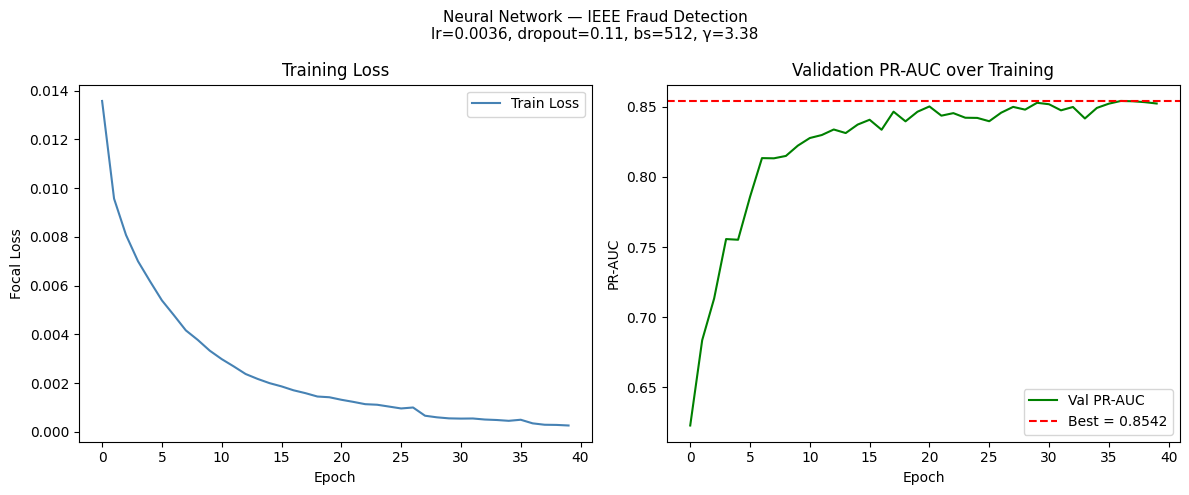

Training curves saved to runs/fraud_nn/nn_training_curves.png


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


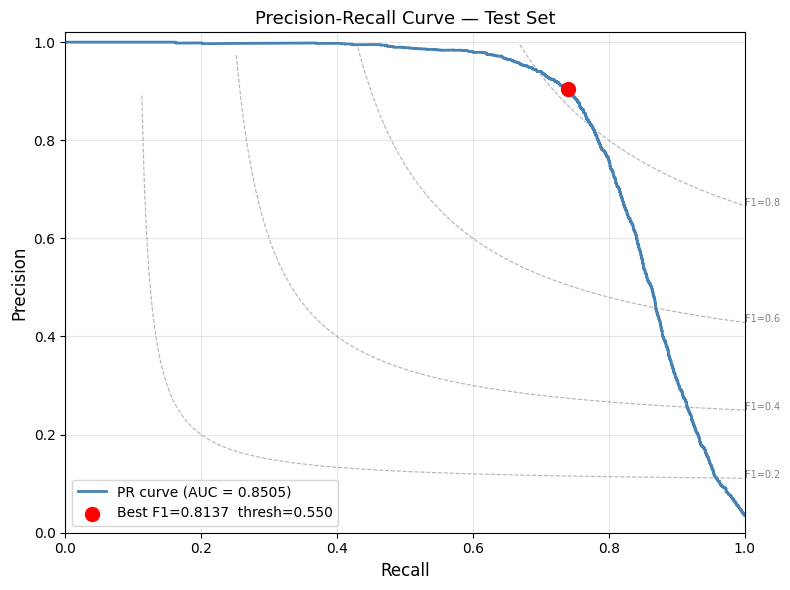

PR curve saved to runs/fraud_nn/pr_curve.png


/Users/anbu/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)



  Final Results at best threshold = 0.550
  Test PR-AUC  : 0.8505
  Test F1      : 0.8137
  Test Recall  : 0.7393
  Test Precision: 0.9048
  Val  Recall  : 0.7561

Final metrics saved to runs/fraud_nn/final_metrics.json
              precision    recall  f1-score   support

   Non-Fraud       0.99      1.00      0.99     85482
       Fraud       0.90      0.74      0.81      3099

    accuracy                           0.99     88581
   macro avg       0.95      0.87      0.90     88581
weighted avg       0.99      0.99      0.99     88581

Model saved to runs/fraud_nn/nn_model.pt

  All outputs saved to: runs/fraud_nn/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt


In [3]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - FocalLoss (gamma tuned by Optuna, range 0.5–5.0)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal loss for binary classification.

    FL(p_t) = -(1 - p_t)^gamma * log(p_t)

    Works on raw logits (no sigmoid needed before calling).
    pos_weight is dropped vs the old BCE setup — focal loss already
    down-weights easy negatives, so stacking pos_weight on top tends
    to over-correct on heavily imbalanced data.  If you want to keep
    class rebalancing you can re-add it, but start without it and
    check whether val PR-AUC improves.

    Args:
        gamma: focusing parameter. 0.0 → standard BCE.
               Typical range: 0.5–5.0.  Paper default: 2.0.
    """

    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # bce_loss is unreduced so we can apply the focal modulation per-sample
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce)                          # probability of the true class
        focal_weight = (1.0 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()
        loss = criterion(model(cat, num), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    all_p = np.array(all_p)
    all_y = np.array(all_y)

    if not np.isfinite(all_p).all():
        # Exploding gradients produced inf/NaN logits — treat as a failed trial
        return 0.0

    return average_precision_score(all_y, all_p)


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )

    # ── Focal loss — no pos_weight needed ─────────────────────────────────────
    criterion = FocalLoss(gamma=config["gamma"])

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)

        # Bail early if loss exploded — avoids NaN propagating to sklearn
        if not np.isfinite(train_loss):
            print(f"  {epoch:>6}/{n_epochs}  loss=NaN — aborting trial")
            break

        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),  # tightened: focal loss is LR-sensitive
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            # ── new: focal loss gamma ─────────────────────────────────────────
            "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    # pos_weight no longer passed — focal loss handles class imbalance
    fraud_rate = train_df[target].mean()
    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
            "gamma",   # focal loss gamma
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"  gamma = {best_config['gamma']:.3f}")
    print(f"{'=' * 60}\n")

    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_train = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    loader_val = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)
    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Focal Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = (
        f"lr={lr:.4f}, dropout={best_config['dropout']:.2f}, "
        f"bs={batch_size}, γ={best_config['gamma']:.2f}"
    )
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    y_true, y_proba = get_predictions(model, loader_test)

    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    f1_scores = (
        2 * precision_pts[:-1] * recall_pts[:-1]
        / (precision_pts[:-1] + recall_pts[:-1] + 1e-8)
    )
    best_idx = np.argmax(f1_scores)
    best_thresh = float(thresholds[best_idx])
    best_f1 = float(f1_scores[best_idx])
    best_recall = float(recall_pts[best_idx])
    best_precision = float(precision_pts[best_idx])

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        best_recall,
        best_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Best F1={best_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_y_true, val_proba = get_predictions(model, loader_val)
    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )
    test_recall = best_recall

    print(f"\n{'=' * 50}")
    print(f"  Final Results at best threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Test PR-AUC  : {test_pr:.4f}")
    print(f"  Test F1      : {best_f1:.4f}")
    print(f"  Test Recall  : {test_recall:.4f}")
    print(f"  Test Precision: {best_precision:.4f}")
    print(f"  Val  Recall  : {val_recall:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "gamma": best_config["gamma"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": best_f1,
        "test_recall": test_recall,
        "test_precision": best_precision,
        "val_recall": val_recall,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "gamma": best_config["gamma"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_recall": test_recall,
        "val_recall": val_recall,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()

### Chatgpt's code for the focal loss change

Device  : mps
Run dir : runs/fraud_nn/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0998      0.4489     6.7s
       2/8    0.0536      0.5170     6.1s
       3/8    0.0453      0.5616     6.2s
       4/8    0.0414      0.5916     6.5s
       5/8    0.0387      0.6290     6.3s
       6/8    0.0364      0.6530     6.4s
       7/8    0.0344      0.6777     6.3s
       8/8    0.0327      0.6866     6.3s
  [Trial  0] val_PR-AUC=0.6866  params={'hidden_dim': 256, 'lr': 0.0010401663679887319, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025, 'gamma': 1.325320294340452}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  

[W 2026-04-08 13:11:14,159] Trial 10 failed with parameters: {'hidden_dim': 256, 'lr': 0.0014519832365831313, 'weight_decay': 0.00011807247257803626, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6451235367845727, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.12582832708219865, 'gamma': 0.5554002630422188} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 440, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 357, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T

  [Trial 10] val_PR-AUC=nan  params={'hidden_dim': 256, 'lr': 0.0014519832365831313, 'weight_decay': 0.00011807247257803626, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6451235367845727, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.12582832708219865, 'gamma': 0.5554002630422188}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0734      0.6399    15.2s


[W 2026-04-08 13:11:44,592] Trial 11 failed with parameters: {'hidden_dim': 256, 'lr': 0.004044849285259287, 'weight_decay': 0.00010709813424917498, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6597073237443142, 'sched_patience': 5, 'sched_factor': 0.6925104332290231, 'dropout': 0.10628450771858666, 'gamma': 0.5302305469515771} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 440, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 357, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/

  [Trial 11] val_PR-AUC=nan  params={'hidden_dim': 256, 'lr': 0.004044849285259287, 'weight_decay': 0.00010709813424917498, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6597073237443142, 'sched_patience': 5, 'sched_factor': 0.6925104332290231, 'dropout': 0.10628450771858666, 'gamma': 0.5302305469515771}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


...

  [Trial 21] val_PR-AUC=nan  params={'hidden_dim': 256, 'lr': 0.004798052477020099, 'weight_decay': 0.00012594933453311487, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6539607167387418, 'sched_patience': 5, 'sched_factor': 0.6372164549154482, 'dropout': 0.30844441022619146, 'gamma': 0.6889730508354774}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0064      0.5816    19.2s
       2/8    0.0037      0.6625    19.2s
       3/8    0.0032      0.7055    18.9s
       4/8    0.0028      0.7296    19.2s
       5/8    0.0025      0.7567    19.2s
       6/8    0.0022      0.7703    18.8s
       7/8    0.0020      0.7912    19.2s
       8/8    0.0018      0.7971    19.2s
  [Trial 22] val_PR-AUC=0.7971  params={'hidden_dim': 256, 'lr': 0.004480868185904097, 'weight_decay': 9.347463354382347e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6483909012084547, 'sched_patience': 5, 'sched_factor': 0.6997653976350742, 'dropout': 0.11045287778321, 'gamma

[W 2026-04-08 13:23:32,278] Trial 25 failed with parameters: {'hidden_dim': 256, 'lr': 0.004560776758063838, 'weight_decay': 4.905019547517595e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6189255225307301, 'sched_patience': 5, 'sched_factor': 0.6296584825280318, 'dropout': 0.28018359448520713, 'gamma': 0.6048399518859131} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 440, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 357, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/i

  [Trial 25] val_PR-AUC=nan  params={'hidden_dim': 256, 'lr': 0.004560776758063838, 'weight_decay': 4.905019547517595e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6189255225307301, 'sched_patience': 5, 'sched_factor': 0.6296584825280318, 'dropout': 0.28018359448520713, 'gamma': 0.6048399518859131}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0183      0.5530    18.9s
       2/8    0.0119      0.6461    19.3s
       3/8    0.0103      0.6993    19.0s
       4/8    0.0092      0.7324    19.1s
       5/8    0.0083      0.7522    19.1s
       6/8    0.0076      0.7806    19.2s
       7/8    0.0070      0.7915    19.2s
       8/8    0.0064      0.8087    19.0s
  [Trial 26] val_PR-AUC=0.8087  params={'hidden_dim': 256, 'lr': 0.003799619268070567, 'weight_decay': 4.095404826760761e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.6106948292012866, 'sched_patience': 5, 'sched_factor': 0.4618150435879287, 'dropout': 0.28129054927574026, 'gam

[W 2026-04-08 13:26:44,342] Trial 27 failed with parameters: {'hidden_dim': 256, 'lr': 0.0012804077633430308, 'weight_decay': 1.6118137119732005e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.7399350572840578, 'sched_patience': 5, 'sched_factor': 0.45278995261147, 'dropout': 0.2869862609876893, 'gamma': 0.5731146843846098} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 440, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/753061184.py", line 357, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ip

  [Trial 27] val_PR-AUC=nan  params={'hidden_dim': 256, 'lr': 0.0012804077633430308, 'weight_decay': 1.6118137119732005e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.7399350572840578, 'sched_patience': 5, 'sched_factor': 0.45278995261147, 'dropout': 0.2869862609876893, 'gamma': 0.5731146843846098}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0213      0.5382    19.0s
       2/8    0.0143      0.6205    19.2s
       3/8    0.0124      0.6620    19.4s
  [Trial 28] val_PR-AUC=0.6620  params={'hidden_dim': 256, 'lr': 0.0015147684957557256, 'weight_decay': 1.3528557212110532e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.7448175025571736, 'sched_patience': 5, 'sched_factor': 0.4487801373250511, 'dropout': 0.2878598303029888, 'gamma': 3.0315259217417694}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0577      0.4296    19.1s
       2/8    0.0284      0.5118    19.1s
       3/8    0.0251 

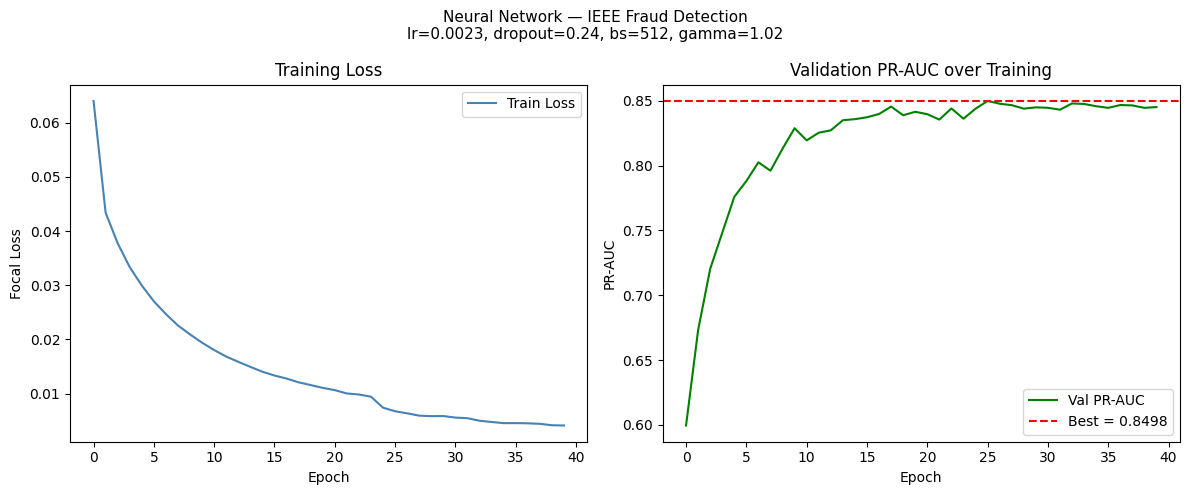

Training curves saved to runs/fraud_nn/nn_training_curves.png


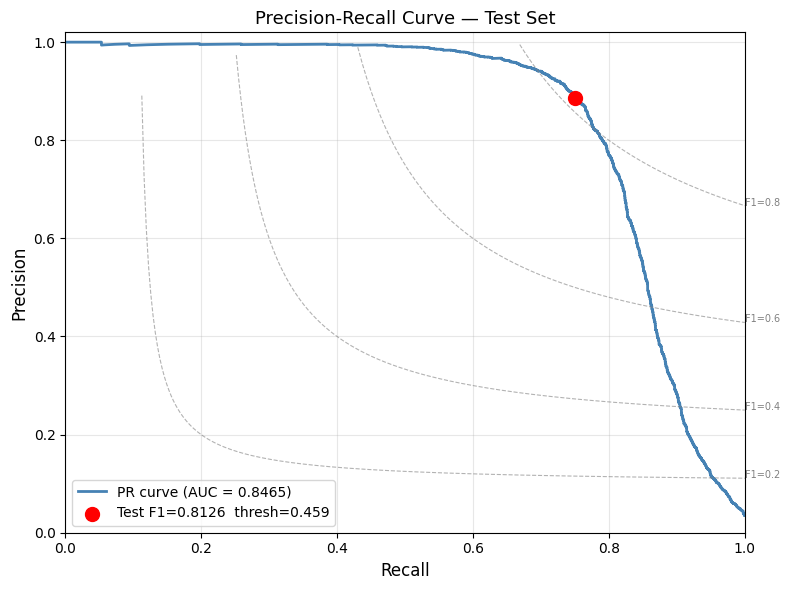

PR curve saved to runs/fraud_nn/pr_curve.png

  Final Results at validation-selected threshold = 0.459
  Val  PR-AUC   : 0.8498
  Test PR-AUC   : 0.8465
  Val  F1       : 0.8257
  Val  Recall   : 0.7590
  Val  Precision: 0.9053
  Test F1       : 0.8126
  Test Recall   : 0.7506
  Test Precision: 0.8858

Final metrics saved to runs/fraud_nn/final_metrics.json
              precision    recall  f1-score   support

   Non-Fraud       0.99      1.00      0.99     85482
       Fraud       0.89      0.75      0.81      3099

    accuracy                           0.99     88581
   macro avg       0.94      0.87      0.90     88581
weighted avg       0.99      0.99      0.99     88581

Model saved to runs/fraud_nn/nn_model.pt

  All outputs saved to: runs/fraud_nn/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt


In [4]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - FocalLoss (gamma tuned by Optuna, range 0.5–5.0)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Binary focal loss on raw logits.

    gamma:
        focusing parameter; 0.0 => BCE
    """

    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce)  # probability assigned to the true class
        focal_weight = (1.0 - p_t).pow(self.gamma)
        loss = focal_weight * bce
        return loss.mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(cat, num)
        if not torch.isfinite(logits).all():
            raise ValueError("Non-finite logits encountered during training.")

        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            raise ValueError("Non-finite loss encountered during training.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered during evaluation.")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered in get_predictions().")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


def find_best_f1_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = int(np.argmax(f1_scores))
    return (
        float(thresholds[best_idx]),
        float(f1_scores[best_idx]),
        float(recall[best_idx]),
        float(precision[best_idx]),
    )


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    use_pin_memory = (device.type == "cuda")

    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = FocalLoss(gamma=config["gamma"])

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)

        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        catch=(ValueError,),
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40
    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    fraud_rate = train_df[target].mean()
    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
            "gamma",
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"  gamma = {best_config['gamma']:.3f}")
    print(f"{'=' * 60}\n")

    use_pin_memory = (device.type == "cuda")
    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_val = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_test = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    if best_state is None:
        raise RuntimeError("Training failed: no valid checkpoint was produced.")

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)

    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Focal Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = (
        f"lr={lr:.4f}, dropout={best_config['dropout']:.2f}, "
        f"bs={batch_size}, gamma={best_config['gamma']:.2f}"
    )
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    # Threshold selection on validation set only
    val_y_true, val_proba = get_predictions(model, loader_val)
    best_thresh, val_best_f1, val_best_recall, val_best_precision = find_best_f1_threshold(
        val_y_true, val_proba
    )

    # Final test evaluation using validation-chosen threshold
    y_true, y_proba = get_predictions(model, loader_test)
    y_pred = (y_proba >= best_thresh).astype(int)

    test_recall = recall_score(y_true, y_pred, zero_division=0)
    test_precision = precision_score(y_true, y_pred, zero_division=0)
    test_f1 = f1_score(y_true, y_pred, zero_division=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)

    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        test_recall,
        test_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Test F1={test_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )

    print(f"\n{'=' * 50}")
    print(f"  Final Results at validation-selected threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC   : {val_pr:.4f}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Val  F1       : {val_best_f1:.4f}")
    print(f"  Val  Recall   : {val_best_recall:.4f}")
    print(f"  Val  Precision: {val_best_precision:.4f}")
    print(f"  Test F1       : {test_f1:.4f}")
    print(f"  Test Recall   : {test_recall:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "gamma": best_config["gamma"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "val_f1": val_best_f1,
        "val_recall": val_recall,
        "val_precision": val_best_precision,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "gamma": best_config["gamma"],
        },
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()

### Chatgpt code to prioritise fraud recall over non-fraud recall

Device  : mps
Run dir : runs/fraud_nn/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0481      0.4236     6.4s
       2/8    0.0218      0.5056     6.3s
       3/8    0.0179      0.5524     6.2s
       4/8    0.0161      0.5731     6.9s
       5/8    0.0150      0.6203     7.4s
       6/8    0.0140      0.6410     6.2s
       7/8    0.0132      0.6710     6.4s
       8/8    0.0125      0.6759     6.3s
  [Trial  0] val_PR-AUC=0.6759  params={'hidden_dim': 256, 'lr': 0.0010401663679887319, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025, 'alpha': 0.6641915784487018, 'gamma': 1.8690900933179198}
   Epoch      Loss  Val PR-AUC     Time
  

[W 2026-04-08 15:15:28,817] Trial 10 failed with parameters: {'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r4

  [Trial 10] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


[W 2026-04-08 15:15:35,090] Trial 11 failed with parameters: {'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400m

  [Trial 11] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0457      0.5006    11.9s


...

  [Trial 27] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.004172852459281787, 'weight_decay': 0.008695276753956621, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7546908915789985, 'sched_patience': 5, 'sched_factor': 0.6993134344664013, 'dropout': 0.49939867501976826, 'alpha': 0.7669050656205482, 'gamma': 0.5275201683869257}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0511      0.5066    11.8s


[W 2026-04-08 15:19:32,326] Trial 28 failed with parameters: {'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400

  [Trial 28] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


[W 2026-04-08 15:19:34,333] Trial 29 failed with parameters: {'hidden_dim': 128, 'lr': 0.003873763227646012, 'weight_decay': 0.006288141198969727, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7165336280884662, 'sched_patience': 5, 'sched_factor': 0.6883274032305536, 'dropout': 0.4972954745546019, 'alpha': 0.7592044620465881, 'gamma': 0.74868917012201} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2608987849.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400mr

  [Trial 29] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003873763227646012, 'weight_decay': 0.006288141198969727, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7165336280884662, 'sched_patience': 5, 'sched_factor': 0.6883274032305536, 'dropout': 0.4972954745546019, 'alpha': 0.7592044620465881, 'gamma': 0.74868917012201}

Best trial: val_PR-AUC=0.7844
Best params: {'hidden_dim': 256, 'lr': 0.004477427984113198, 'weight_decay': 0.007076022085822006, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6047821669899485, 'sched_patience': 3, 'sched_factor': 0.41145858569464455, 'dropout': 0.4633063543866615, 'alpha': 0.6838466617334403, 'gamma': 1.152026924410504}

Full training for 40 epochs with best config
  alpha = 0.684
  gamma = 1.152

   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
    Saved -> runs/fraud_nn/best.pt
    Saved -> runs/fraud_nn/last.pt
       1/40    0.0308      0.5513    11.6s
    Saved -> runs/fraud_nn/best.pt
    Saved -> runs/fraud_n

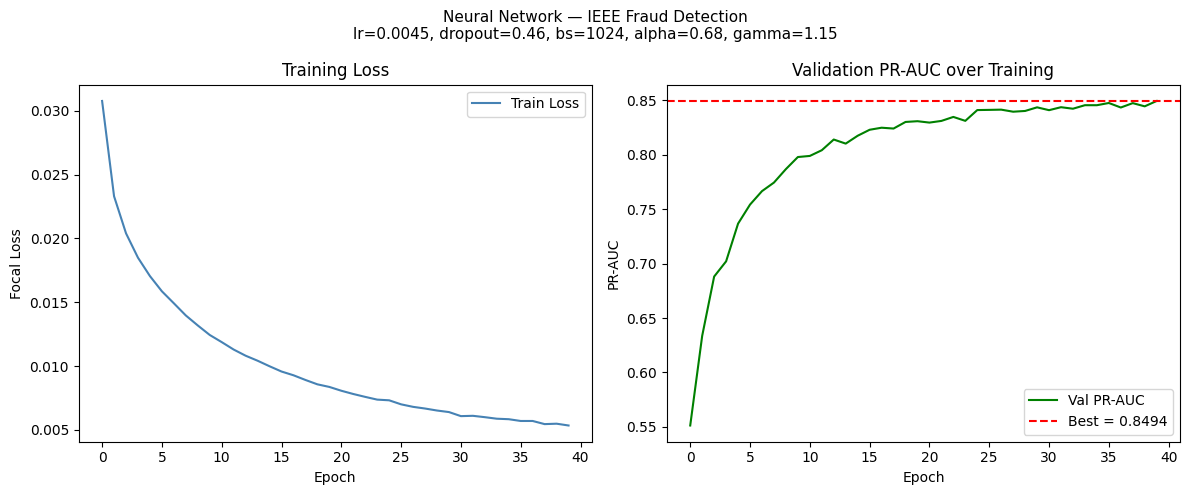

Training curves saved to runs/fraud_nn/nn_training_curves.png


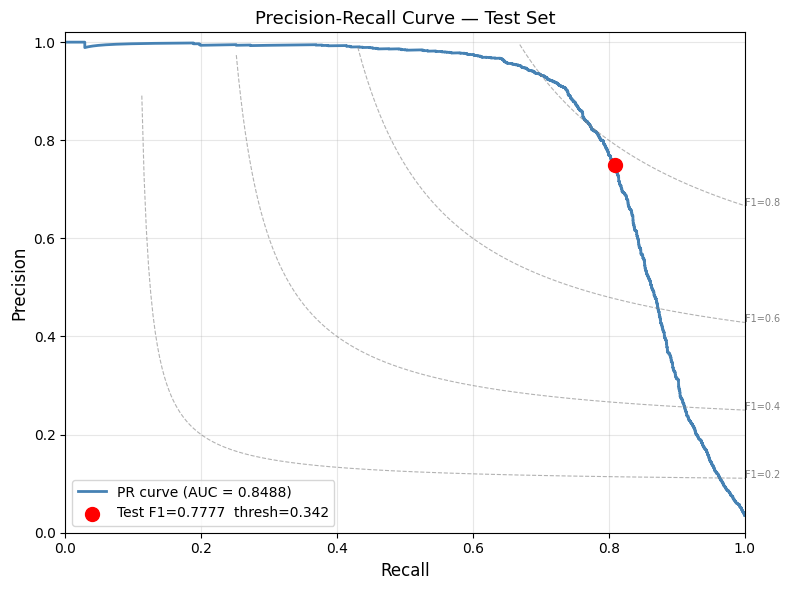

PR curve saved to runs/fraud_nn/pr_curve.png

  Final Results at validation-selected threshold = 0.342
  Val  PR-AUC   : 0.8494
  Test PR-AUC   : 0.8488
  Val  F2.0 : 0.7957
  Val  Recall   : 0.8025
  Val  Precision: 0.7697
  Test F1       : 0.7777
  Test Recall   : 0.8083
  Test Precision: 0.7493

Final metrics saved to runs/fraud_nn/final_metrics.json
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.75      0.81      0.78      3099

    accuracy                           0.98     88581
   macro avg       0.87      0.90      0.88     88581
weighted avg       0.98      0.98      0.98     88581

Model saved to runs/fraud_nn/nn_model.pt

  All outputs saved to: runs/fraud_nn/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt


In [5]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - Alpha-balanced FocalLoss (alpha + gamma tuned by Optuna)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
  - Threshold selected on validation set using F-beta (beta=2.0) to prioritise recall
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Alpha-balanced binary focal loss on raw logits.

    alpha:
        weight for positive class (fraud)
        higher alpha -> more emphasis on fraud examples

    gamma:
        focusing parameter; 0.0 => BCE
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_weight = alpha_t * (1.0 - p_t).pow(self.gamma)

        loss = focal_weight * bce
        return loss.mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(cat, num)
        if not torch.isfinite(logits).all():
            raise ValueError("Non-finite logits encountered during training.")

        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            raise ValueError("Non-finite loss encountered during training.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered during evaluation.")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered in get_predictions().")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


def find_best_fbeta_threshold(y_true, y_proba, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0

    beta2 = beta ** 2
    scores = (
        (1 + beta2) * precision[:-1] * recall[:-1]
        / (beta2 * precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = int(np.argmax(scores))
    return (
        float(thresholds[best_idx]),
        float(scores[best_idx]),
        float(recall[best_idx]),
        float(precision[best_idx]),
    )


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    use_pin_memory = (device.type == "cuda")

    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = FocalLoss(alpha=config["alpha"], gamma=config["gamma"])

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)

        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "alpha": trial.suggest_float("alpha", 0.60, 0.95),
            "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        catch=(ValueError,),
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40
    beta_for_threshold = 2.0

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    fraud_rate = train_df[target].mean()
    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
            "alpha",
            "gamma",
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"  alpha = {best_config['alpha']:.3f}")
    print(f"  gamma = {best_config['gamma']:.3f}")
    print(f"{'=' * 60}\n")

    use_pin_memory = (device.type == "cuda")
    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_val = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_test = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    if best_state is None:
        raise RuntimeError("Training failed: no valid checkpoint was produced.")

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)

    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Focal Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = (
        f"lr={lr:.4f}, dropout={best_config['dropout']:.2f}, "
        f"bs={batch_size}, alpha={best_config['alpha']:.2f}, "
        f"gamma={best_config['gamma']:.2f}"
    )
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    # Select threshold on validation only, using F-beta to prioritise recall
    val_y_true, val_proba = get_predictions(model, loader_val)
    best_thresh, val_best_fbeta, val_best_recall, val_best_precision = find_best_fbeta_threshold(
        val_y_true,
        val_proba,
        beta=beta_for_threshold,
    )

    # Final test evaluation using validation-selected threshold
    y_true, y_proba = get_predictions(model, loader_test)
    y_pred = (y_proba >= best_thresh).astype(int)

    test_recall = recall_score(y_true, y_pred, zero_division=0)
    test_precision = precision_score(y_true, y_pred, zero_division=0)
    test_f1 = f1_score(y_true, y_pred, zero_division=0)

    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        test_recall,
        test_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Test F1={test_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )

    print(f"\n{'=' * 50}")
    print(f"  Final Results at validation-selected threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC   : {val_pr:.4f}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Val  F{beta_for_threshold:.1f} : {val_best_fbeta:.4f}")
    print(f"  Val  Recall   : {val_best_recall:.4f}")
    print(f"  Val  Precision: {val_best_precision:.4f}")
    print(f"  Test F1       : {test_f1:.4f}")
    print(f"  Test Recall   : {test_recall:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "alpha": best_config["alpha"],
            "gamma": best_config["gamma"],
        },
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "val_fbeta": val_best_fbeta,
        "val_recall": val_recall,
        "val_precision": val_best_precision,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "alpha": best_config["alpha"],
            "gamma": best_config["gamma"],
        },
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()

## Chatgpt - F2 focused version

Device  : mps
Run dir : runs/fraud_nn/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0502      0.4342     6.5s
       2/8    0.0217      0.5002     6.1s
       3/8    0.0178      0.5504     6.3s
       4/8    0.0160      0.5870     6.2s
       5/8    0.0150      0.6197     6.2s
       6/8    0.0141      0.6451     6.2s
       7/8    0.0133      0.6552     6.2s
       8/8    0.0125      0.6752     6.2s
  [Trial  0] val_PR-AUC=0.6752  params={'hidden_dim': 256, 'lr': 0.0010401663679887319, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025, 'alpha': 0.6641915784487018, 'gamma': 1.8690900933179198}
   Epoch      Loss  Val PR-AUC     Time
  

[W 2026-04-08 17:06:41,211] Trial 10 failed with parameters: {'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r4

  [Trial 10] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


[W 2026-04-08 17:06:42,004] Trial 11 failed with parameters: {'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400m

  [Trial 11] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0470      0.5139    10.5s


...

  [Trial 27] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.004172852459281787, 'weight_decay': 0.008695276753956621, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7546908915789985, 'sched_patience': 5, 'sched_factor': 0.6993134344664013, 'dropout': 0.49939867501976826, 'alpha': 0.7669050656205482, 'gamma': 0.5275201683869257}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0493      0.5305    11.5s
       2/8    0.0361      0.6056    11.6s


[W 2026-04-08 17:10:55,526] Trial 28 failed with parameters: {'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400

  [Trial 28] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


[W 2026-04-08 17:10:56,046] Trial 29 failed with parameters: {'hidden_dim': 128, 'lr': 0.003873763227646012, 'weight_decay': 0.006288141198969727, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7165336280884662, 'sched_patience': 5, 'sched_factor': 0.6883274032305536, 'dropout': 0.4972954745546019, 'alpha': 0.7592044620465881, 'gamma': 0.74868917012201} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 453, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/2655276575.py", line 369, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400mr

  [Trial 29] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003873763227646012, 'weight_decay': 0.006288141198969727, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7165336280884662, 'sched_patience': 5, 'sched_factor': 0.6883274032305536, 'dropout': 0.4972954745546019, 'alpha': 0.7592044620465881, 'gamma': 0.74868917012201}

Best trial: val_PR-AUC=0.7856
Best params: {'hidden_dim': 256, 'lr': 0.004477427984113198, 'weight_decay': 0.007076022085822006, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6047821669899485, 'sched_patience': 3, 'sched_factor': 0.41145858569464455, 'dropout': 0.4633063543866615, 'alpha': 0.6838466617334403, 'gamma': 1.152026924410504}

Full training for 40 epochs with best config
  alpha = 0.684
  gamma = 1.152

   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
    Saved -> runs/fraud_nn/best.pt
    Saved -> runs/fraud_nn/last.pt
       1/40    0.0332      0.5536    11.6s
    Saved -> runs/fraud_nn/best.pt
    Saved -> runs/fraud_n

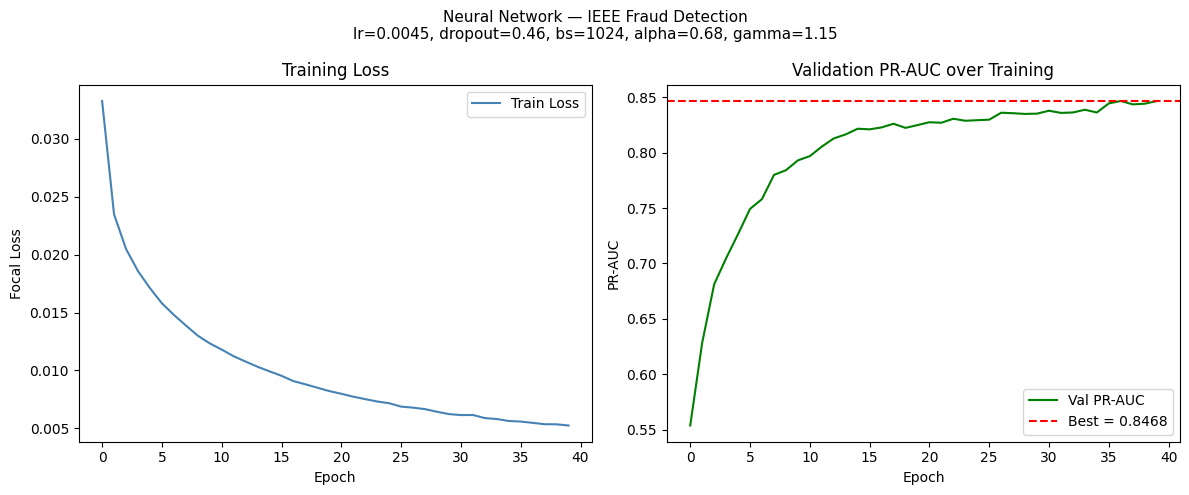

Training curves saved to runs/fraud_nn/nn_training_curves.png


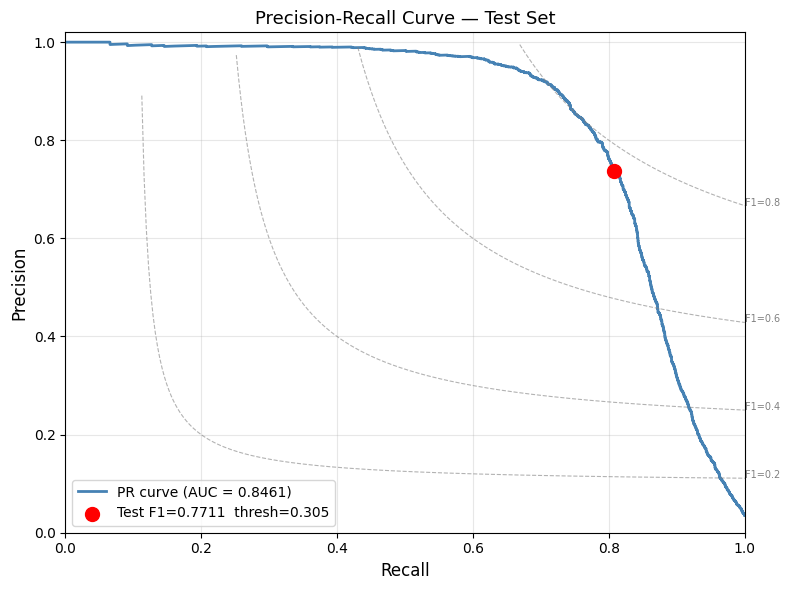

PR curve saved to runs/fraud_nn/pr_curve.png

  Final Results at validation-selected threshold = 0.305
  Val  PR-AUC   : 0.8468
  Test PR-AUC   : 0.8461
  Val  F2.0     : 0.7902
  Val  Recall   : 0.8006
  Val  Precision: 0.7511
  Test F1       : 0.7711
  Test Recall   : 0.8077
  Test Precision: 0.7377

Final metrics saved to runs/fraud_nn/final_metrics.json
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.74      0.81      0.77      3099

    accuracy                           0.98     88581
   macro avg       0.87      0.90      0.88     88581
weighted avg       0.98      0.98      0.98     88581

Model saved to runs/fraud_nn/nn_model.pt

  All outputs saved to: runs/fraud_nn/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt


In [6]:
"""
IEEE-CIS Fraud Detection — Neural Network
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - Alpha-balanced FocalLoss (alpha + gamma tuned by Optuna)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
  - Threshold selected on validation set using F2 to prioritise recall
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Alpha-balanced binary focal loss on raw logits.

    alpha:
        weight for positive class (fraud)
        higher alpha -> more emphasis on fraud examples

    gamma:
        focusing parameter; 0.0 => BCE
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_weight = alpha_t * (1.0 - p_t).pow(self.gamma)

        loss = focal_weight * bce
        return loss.mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(cat, num)
        if not torch.isfinite(logits).all():
            raise ValueError("Non-finite logits encountered during training.")

        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            raise ValueError("Non-finite loss encountered during training.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered during evaluation.")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered in get_predictions().")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


def find_best_fbeta_threshold(y_true, y_proba, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0

    beta2 = beta ** 2
    scores = (
        (1 + beta2) * precision[:-1] * recall[:-1]
        / (beta2 * precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = int(np.argmax(scores))
    return (
        float(thresholds[best_idx]),
        float(scores[best_idx]),
        float(recall[best_idx]),
        float(precision[best_idx]),
    )


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    use_pin_memory = (device.type == "cuda")

    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = FocalLoss(alpha=config["alpha"], gamma=config["gamma"])

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)

        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "alpha": trial.suggest_float("alpha", 0.60, 0.95),
            "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        catch=(ValueError,),
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    run_dir = os.path.join("runs", "fraud_nn")
    n_epochs_full = 40
    beta_for_threshold = 2.0

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    fraud_rate = train_df[target].mean()
    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
            "alpha",
            "gamma",
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"  alpha = {best_config['alpha']:.3f}")
    print(f"  gamma = {best_config['gamma']:.3f}")
    print(f"{'=' * 60}\n")

    use_pin_memory = (device.type == "cuda")
    lr = best_config["lr"]
    batch_size = best_config["batch_size"]

    loader_val = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_test = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    if best_state is None:
        raise RuntimeError("Training failed: no valid checkpoint was produced.")

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)

    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Focal Loss")
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    cfg_label = (
        f"lr={lr:.4f}, dropout={best_config['dropout']:.2f}, "
        f"bs={batch_size}, alpha={best_config['alpha']:.2f}, "
        f"gamma={best_config['gamma']:.2f}"
    )
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.show()
    print(f"Training curves saved to {curves_path}")

    # Select threshold on validation only, using F2 to prioritise recall
    val_y_true, val_proba = get_predictions(model, loader_val)
    best_thresh, val_best_f2, val_best_recall, val_best_precision = find_best_fbeta_threshold(
        val_y_true,
        val_proba,
        beta=beta_for_threshold,
    )

    # Final test evaluation using validation-selected threshold
    y_true, y_proba = get_predictions(model, loader_test)
    y_pred = (y_proba >= best_thresh).astype(int)

    test_recall = recall_score(y_true, y_pred, zero_division=0)
    test_precision = precision_score(y_true, y_pred, zero_division=0)
    test_f1 = f1_score(y_true, y_pred, zero_division=0)

    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        test_recall,
        test_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Test F1={test_f1:.4f}  thresh={best_thresh:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    pr_curve_path = os.path.join(run_dir, "pr_curve.png")
    plt.savefig(pr_curve_path, dpi=150)
    plt.show()
    print(f"PR curve saved to {pr_curve_path}")

    val_recall = recall_score(
        val_y_true,
        (val_proba >= best_thresh).astype(int),
        zero_division=0,
    )

    print(f"\n{'=' * 50}")
    print(f"  Final Results at validation-selected threshold = {best_thresh:.3f}")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC   : {val_pr:.4f}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Val  F2.0     : {val_best_f2:.4f}")
    print(f"  Val  Recall   : {val_best_recall:.4f}")
    print(f"  Val  Precision: {val_best_precision:.4f}")
    print(f"  Test F1       : {test_f1:.4f}")
    print(f"  Test Recall   : {test_recall:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")

    final_metrics = {
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "alpha": best_config["alpha"],
            "gamma": best_config["gamma"],
        },
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "val_f2": val_best_f2,
        "val_recall": val_recall,
        "val_precision": val_best_precision,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
    }

    metrics_path = os.path.join(run_dir, "final_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    model_path = os.path.join(run_dir, "nn_model.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": {
            "lr": lr,
            "batch_size": batch_size,
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "alpha": best_config["alpha"],
            "gamma": best_config["gamma"],
        },
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_f1": test_f1,
        "test_recall": test_recall,
        "test_precision": test_precision,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    print(f"\n{'=' * 50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'=' * 50}")


if __name__ == "__main__":
    main()

## chatgpt - baco loss vs focal loss


In [7]:
"""
IEEE-CIS Fraud Detection — Fair Comparison:
BCEWithLogitsLoss + pos_weight  vs  Alpha-Balanced Focal Loss
using the SAME architecture and SAME F2 threshold policy.

What this script does:
- Trains two models with identical architecture / training loop
- Model A: BCEWithLogitsLoss(pos_weight=neg/pos)
- Model B: Alpha-balanced FocalLoss(alpha, gamma)
- Both use:
    * embeddings for categorical features
    * scaled numerical features
    * 3 hidden layers: H -> H/2 -> H/4
    * Linear -> BatchNorm -> GELU -> Dropout
    * AdamW + Lookahead
    * ReduceLROnPlateau on validation PR-AUC
    * Optuna TPE search
    * gradient clipping
- Threshold is selected on VALIDATION ONLY using F2
- Final comparison is reported on TEST using the validation-selected threshold

Folder outputs:
runs/fraud_compare/
    bce/
    focal/
    comparison_summary.json
"""

import os
import json
import pickle
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Losses ─────────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Alpha-balanced binary focal loss on raw logits.
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_weight = alpha_t * (1.0 - p_t).pow(self.gamma)

        return (focal_weight * bce).mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [[p.to(device) for p in g] for g in state["slow_weights"]]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def get_pos_weight(y_series, device):
    n_neg = (y_series == 0).sum()
    n_pos = (y_series == 1).sum()
    return torch.tensor(n_neg / n_pos, dtype=torch.float32, device=device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(cat, num)
        if not torch.isfinite(logits).all():
            raise ValueError("Non-finite logits encountered during training.")

        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            raise ValueError("Non-finite loss encountered during training.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered during evaluation.")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered in get_predictions().")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


def find_best_fbeta_threshold(y_true, y_proba, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0

    beta2 = beta ** 2
    scores = (
        (1 + beta2) * precision[:-1] * recall[:-1]
        / (beta2 * precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = int(np.argmax(scores))
    return (
        float(thresholds[best_idx]),
        float(scores[best_idx]),
        float(recall[best_idx]),
        float(precision[best_idx]),
    )


def plot_confusion_matrix(y_true, y_proba, threshold, run_dir, title_suffix=""):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix{title_suffix} — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix{title_suffix} — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


def plot_training_curves(history, best_val_pr_auc, run_dir, cfg_label, loss_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(loss_name)
    ax.set_title("Training Loss")
    ax.legend()

    ax = axes[1]
    ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
    ax.axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("PR-AUC")
    ax.set_title("Validation PR-AUC over Training")
    ax.legend()

    plt.suptitle(cfg_label, fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "training_curves.png"), dpi=150)
    plt.close()


def plot_pr_curve(y_true, y_proba, test_pr, threshold, test_recall, test_precision, test_f1, run_dir, title):
    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})",
    )
    ax.scatter(
        test_recall,
        test_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"Test F1={test_f1:.4f}  thresh={threshold:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "pr_curve.png"), dpi=150)
    plt.close()


# ── Training core ──────────────────────────────────────────────────────────────
def make_criterion(loss_type, config, pos_weight):
    if loss_type == "bce":
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    if loss_type == "focal":
        return FocalLoss(alpha=config["alpha"], gamma=config["gamma"])
    raise ValueError(f"Unknown loss_type: {loss_type}")


def run_training(
    config,
    loss_type,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    pos_weight,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    use_pin_memory = (device.type == "cuda")

    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = make_criterion(loss_type, config, pos_weight)

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0
    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                torch.save({
                    "epoch": epoch,
                    "val_pr_auc": val_pr,
                    "config": config,
                    "loss_type": loss_type,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "cat_cols": metadata["cat_cols"],
                    "num_cols": metadata["num_cols"],
                    "vocab_sizes": metadata["vocab_sizes"],
                }, os.path.join(run_dir, "best.pt"))

        if run_dir:
            torch.save({
                "epoch": epoch,
                "val_pr_auc": val_pr,
                "config": config,
                "loss_type": loss_type,
                "model_state_dict": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "cat_cols": metadata["cat_cols"],
                "num_cols": metadata["num_cols"],
                "vocab_sizes": metadata["vocab_sizes"],
            }, os.path.join(run_dir, "last.pt"))

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        print(
            f"[{loss_type.upper()}] "
            f"{epoch:>3}/{n_epochs}  loss={train_loss:.4f}  val_pr={val_pr:.4f}  time={elapsed:.1f}s"
        )

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


def bayesian_search(
    loss_type,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    pos_weight,
    n_trials=20,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        }

        if loss_type == "focal":
            config["alpha"] = trial.suggest_float("alpha", 0.60, 0.95)
            config["gamma"] = trial.suggest_float("gamma", 0.5, 5.0)

        val_pr, _, _ = run_training(
            config=config,
            loss_type=loss_type,
            train_ds=train_ds,
            val_ds=val_ds,
            vocab_sizes=vocab_sizes,
            cat_cols=cat_cols,
            num_cols=num_cols,
            metadata=metadata,
            device=device,
            pos_weight=pos_weight,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        catch=(ValueError,),
        callbacks=[
            lambda s, t: print(
                f"[{loss_type.upper()}][Trial {t.number:>2}] "
                f"val_PR-AUC={(t.value if t.value is not None else float('nan')):.4f} "
                f"params={t.params}"
            )
        ],
    )

    print(f"\n[{loss_type.upper()}] Best trial: val_PR-AUC={study.best_value:.4f}")
    print(f"[{loss_type.upper()}] Best params: {study.best_params}")
    return study.best_params, study


def train_and_evaluate_one(
    loss_type,
    base_run_dir,
    train_ds,
    val_ds,
    test_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    pos_weight,
    n_trials=20,
    n_epochs_tune=8,
    n_epochs_full=40,
    beta_for_threshold=2.0,
):
    run_dir = os.path.join(base_run_dir, loss_type)
    os.makedirs(run_dir, exist_ok=True)

    best_params, study = bayesian_search(
        loss_type=loss_type,
        train_ds=train_ds,
        val_ds=val_ds,
        vocab_sizes=vocab_sizes,
        cat_cols=cat_cols,
        num_cols=num_cols,
        metadata=metadata,
        device=device,
        pos_weight=pos_weight,
        n_trials=n_trials,
        n_epochs_tune=n_epochs_tune,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        "hidden_dim": best_params["hidden_dim"],
        "lr": best_params["lr"],
        "weight_decay": best_params["weight_decay"],
        "batch_size": best_params["batch_size"],
        "la_k": best_params["la_k"],
        "la_alpha": best_params["la_alpha"],
        "sched_patience": best_params["sched_patience"],
        "sched_factor": best_params["sched_factor"],
        "dropout": best_params["dropout"],
    }
    if loss_type == "focal":
        best_config["alpha"] = best_params["alpha"]
        best_config["gamma"] = best_params["gamma"]

    best_val_pr_auc, best_state, history = run_training(
        config=best_config,
        loss_type=loss_type,
        train_ds=train_ds,
        val_ds=val_ds,
        vocab_sizes=vocab_sizes,
        cat_cols=cat_cols,
        num_cols=num_cols,
        metadata=metadata,
        device=device,
        pos_weight=pos_weight,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
        trial=None,
    )

    if best_state is None:
        raise RuntimeError(f"{loss_type}: no valid checkpoint was produced.")

    use_pin_memory = (device.type == "cuda")
    batch_size = best_config["batch_size"]

    loader_val = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=use_pin_memory)
    loader_test = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=use_pin_memory)

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)
    model.load_state_dict(best_state)

    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    val_y_true, val_proba = get_predictions(model, loader_val)
    best_thresh, val_best_f2, val_best_recall, val_best_precision = find_best_fbeta_threshold(
        val_y_true, val_proba, beta=beta_for_threshold
    )

    y_true, y_proba = get_predictions(model, loader_test)
    y_pred = (y_proba >= best_thresh).astype(int)

    test_recall = recall_score(y_true, y_pred, zero_division=0)
    test_precision = precision_score(y_true, y_pred, zero_division=0)
    test_f1 = f1_score(y_true, y_pred, zero_division=0)

    loss_label = "BCE Loss" if loss_type == "bce" else "Focal Loss"
    cfg_label = (
        f"{loss_type.upper()} | lr={best_config['lr']:.4f}, "
        f"dropout={best_config['dropout']:.2f}, bs={batch_size}"
    )
    if loss_type == "focal":
        cfg_label += f", alpha={best_config['alpha']:.2f}, gamma={best_config['gamma']:.2f}"

    plot_training_curves(history, best_val_pr_auc, run_dir, cfg_label, loss_label)
    plot_pr_curve(
        y_true=y_true,
        y_proba=y_proba,
        test_pr=test_pr,
        threshold=best_thresh,
        test_recall=test_recall,
        test_precision=test_precision,
        test_f1=test_f1,
        run_dir=run_dir,
        title=f"{loss_type.upper()} — PR Curve (Test)",
    )
    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir, title_suffix=f" ({loss_type.upper()})")

    final_metrics = {
        "loss_type": loss_type,
        "best_config": deepcopy(best_config),
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": float(val_pr),
        "test_pr_auc": float(test_pr),
        "best_thresh": float(best_thresh),
        "val_f2": float(val_best_f2),
        "val_recall": float(val_best_recall),
        "val_precision": float(val_best_precision),
        "test_f1": float(test_f1),
        "test_recall": float(test_recall),
        "test_precision": float(test_precision),
    }

    with open(os.path.join(run_dir, "final_metrics.json"), "w") as f:
        json.dump(final_metrics, f, indent=2)

    torch.save({
        "model_state_dict": best_state,
        "loss_type": loss_type,
        "best_config": deepcopy(best_config),
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": float(val_pr),
        "test_pr_auc": float(test_pr),
        "best_thresh": float(best_thresh),
        "test_f1": float(test_f1),
        "test_recall": float(test_recall),
        "test_precision": float(test_precision),
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, os.path.join(run_dir, "nn_model.pt"))

    print(f"\n[{loss_type.upper()}] Final Results at validation-selected threshold = {best_thresh:.3f}")
    print(f"  Val  PR-AUC   : {val_pr:.4f}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Val  F2.0     : {val_best_f2:.4f}")
    print(f"  Val  Recall   : {val_best_recall:.4f}")
    print(f"  Val  Precision: {val_best_precision:.4f}")
    print(f"  Test F1       : {test_f1:.4f}")
    print(f"  Test Recall   : {test_recall:.4f}")
    print(f"  Test Precision: {test_precision:.4f}")

    report = classification_report(y_true, y_pred, target_names=["Non-Fraud", "Fraud"])
    print(report)

    return final_metrics


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    base_run_dir = os.path.join("runs", "fraud_compare")
    n_trials = 20
    n_epochs_tune = 8
    n_epochs_full = 40
    beta_for_threshold = 2.0

    os.makedirs(base_run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {base_run_dir}/")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    fraud_rate = train_df[target].mean()
    pos_weight = get_pos_weight(train_df[target], device)

    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")
    print(f"pos_weight  : {pos_weight.item():.2f}")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    print("\n" + "=" * 70)
    print("Training BCEWithLogitsLoss + pos_weight with F2 threshold policy")
    print("=" * 70)
    bce_results = train_and_evaluate_one(
        loss_type="bce",
        base_run_dir=base_run_dir,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        vocab_sizes=vocab_sizes,
        cat_cols=cat_cols,
        num_cols=num_cols,
        metadata=metadata,
        device=device,
        pos_weight=pos_weight,
        n_trials=n_trials,
        n_epochs_tune=n_epochs_tune,
        n_epochs_full=n_epochs_full,
        beta_for_threshold=beta_for_threshold,
    )

    print("\n" + "=" * 70)
    print("Training Focal Loss with F2 threshold policy")
    print("=" * 70)
    focal_results = train_and_evaluate_one(
        loss_type="focal",
        base_run_dir=base_run_dir,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        vocab_sizes=vocab_sizes,
        cat_cols=cat_cols,
        num_cols=num_cols,
        metadata=metadata,
        device=device,
        pos_weight=pos_weight,
        n_trials=n_trials,
        n_epochs_tune=n_epochs_tune,
        n_epochs_full=n_epochs_full,
        beta_for_threshold=beta_for_threshold,
    )

    comparison = {
        "threshold_policy": f"validation-selected F{beta_for_threshold:.1f}",
        "bce_pos_weight": bce_results,
        "focal": focal_results,
    }

    with open(os.path.join(base_run_dir, "comparison_summary.json"), "w") as f:
        json.dump(comparison, f, indent=2)

    print("\n" + "=" * 70)
    print("FINAL COMPARISON")
    print("=" * 70)
    print(f"BCE   | Test PR-AUC={bce_results['test_pr_auc']:.4f} | "
          f"Recall={bce_results['test_recall']:.4f} | "
          f"Precision={bce_results['test_precision']:.4f} | "
          f"F1={bce_results['test_f1']:.4f}")
    print(f"Focal | Test PR-AUC={focal_results['test_pr_auc']:.4f} | "
          f"Recall={focal_results['test_recall']:.4f} | "
          f"Precision={focal_results['test_precision']:.4f} | "
          f"F1={focal_results['test_f1']:.4f}")

    print(f"\nSaved comparison summary to {os.path.join(base_run_dir, 'comparison_summary.json')}")


if __name__ == "__main__":
    main()

Device  : mps
Run dir : runs/fraud_compare/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)
pos_weight  : 27.58

Training BCEWithLogitsLoss + pos_weight with F2 threshold policy
[BCE]   1/8  loss=0.9221  val_pr=0.5035  time=6.7s
[BCE]   2/8  loss=0.7770  val_pr=0.5578  time=6.5s
[BCE]   3/8  loss=0.7100  val_pr=0.5777  time=6.5s
[BCE]   4/8  loss=0.6570  val_pr=0.6269  time=6.7s
[BCE]   5/8  loss=0.6153  val_pr=0.6400  time=6.6s
[BCE]   6/8  loss=0.5781  val_pr=0.6548  time=6.6s
[BCE]   7/8  loss=0.5484  val_pr=0.6847  time=6.4s
[BCE]   8/8  loss=0.5175  val_pr=0.6714  time=6.5s
[BCE][Trial  0] val_PR-AUC=0.6847 params={'hidden_dim': 256, 'lr': 0.0010401663679887319, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025}
[BCE]   1/8  loss=0.8099  val_pr=0.5758  time=16.9s
[BCE]   2/8  loss=0.63

[W 2026-04-08 19:40:34,481] Trial 10 failed with parameters: {'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 551, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 458, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r4

[FOCAL][Trial 10] val_PR-AUC=nan params={'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113}
[FOCAL]   1/8  loss=0.0476  val_pr=0.5168  time=11.9s


[W 2026-04-08 19:40:57,551] Trial 11 failed with parameters: {'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 551, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 458, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r400m

[FOCAL][Trial 11] val_PR-AUC=nan params={'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925}


...

[FOCAL][Trial 17] val_PR-AUC=nan params={'hidden_dim': 128, 'lr': 0.004778205281348532, 'weight_decay': 0.006951011408043272, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7123161127609905, 'sched_patience': 5, 'sched_factor': 0.6965108784574399, 'dropout': 0.48703016077738503, 'alpha': 0.7708538860204946, 'gamma': 0.6160832963396734}
[FOCAL]   1/8  loss=0.0448  val_pr=0.5308  time=11.8s


[W 2026-04-08 19:42:45,233] Trial 18 failed with parameters: {'hidden_dim': 128, 'lr': 0.004422644001434328, 'weight_decay': 0.006592318760277418, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6941468837236077, 'sched_patience': 5, 'sched_factor': 0.6614035607563236, 'dropout': 0.48857063853491123, 'alpha': 0.7768547057040319, 'gamma': 0.5995510295755302} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 551, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 458, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r40

[FOCAL][Trial 18] val_PR-AUC=nan params={'hidden_dim': 128, 'lr': 0.004422644001434328, 'weight_decay': 0.006592318760277418, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6941468837236077, 'sched_patience': 5, 'sched_factor': 0.6614035607563236, 'dropout': 0.48857063853491123, 'alpha': 0.7768547057040319, 'gamma': 0.5995510295755302}
[FOCAL]   1/8  loss=0.0461  val_pr=0.5145  time=12.2s


[W 2026-04-08 19:43:08,131] Trial 19 failed with parameters: {'hidden_dim': 128, 'lr': 0.0044263666531377055, 'weight_decay': 0.0037992583168395644, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7253085663206511, 'sched_patience': 5, 'sched_factor': 0.6843508467731599, 'dropout': 0.49629941507979686, 'alpha': 0.756370805295757, 'gamma': 0.6518624943662331} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 551, in objective
    val_pr, _, _ = run_training(
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_50456/1911707277.py", line 458, in run_training
    train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
  File "/var/folders/w3/r4

[FOCAL][Trial 19] val_PR-AUC=nan params={'hidden_dim': 128, 'lr': 0.0044263666531377055, 'weight_decay': 0.0037992583168395644, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7253085663206511, 'sched_patience': 5, 'sched_factor': 0.6843508467731599, 'dropout': 0.49629941507979686, 'alpha': 0.756370805295757, 'gamma': 0.6518624943662331}

[FOCAL] Best trial: val_PR-AUC=0.7805
[FOCAL] Best params: {'hidden_dim': 256, 'lr': 0.004477427984113198, 'weight_decay': 0.007076022085822006, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6047821669899485, 'sched_patience': 3, 'sched_factor': 0.41145858569464455, 'dropout': 0.4633063543866615, 'alpha': 0.6838466617334403, 'gamma': 1.152026924410504}
[FOCAL]   1/40  loss=0.0309  val_pr=0.5634  time=12.0s
[FOCAL]   2/40  loss=0.0231  val_pr=0.6277  time=12.2s
[FOCAL]   3/40  loss=0.0202  val_pr=0.6852  time=12.1s
[FOCAL]   4/40  loss=0.0183  val_pr=0.7123  time=11.8s
[FOCAL]   5/40  loss=0.0168  val_pr=0.7340  time=11.5s
[FOCAL]   6/40  loss=0.0156  val_

## Asked claude to improve the best basic model dropout to optimise for higher recall for fraud than non fraud

In [3]:
"""
IEEE-CIS Fraud Detection — Neural Network (High-Recall variant)
Changes vs baseline:
  - Focal Loss replaces BCEWithLogitsLoss (alpha/gamma tunable)
  - pos_weight multiplier to further up-weight fraud class
  - Threshold selected by F-beta (beta=2) instead of F1, so recall is
    weighted 4x more than precision in the optimisation
  - Optional hard recall floor: if you set MIN_RECALL, the threshold is
    chosen as the lowest value that keeps recall >= MIN_RECALL
  - All other architecture / training logic unchanged
"""

import os
import json
import pickle
import time
import tqdm as notebook_tqdm
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    fbeta_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Recall target ──────────────────────────────────────────────────────────────
# Set to e.g. 0.90 to enforce a hard recall floor when picking threshold.
# Set to None to instead use the F-beta optimum (softer, usually higher F1).
MIN_RECALL: float | None = 0.90          # CHANGED — set your target here
FBETA: float = 2.0                        # CHANGED — beta>1 → recall weighted more

# ── pos_weight multiplier ──────────────────────────────────────────────────────
# Baseline uses neg/pos ratio (~28). Multiplying it pushes the model to
# predict fraud more aggressively during training.
POS_WEIGHT_MULTIPLIER: float = 2.0       # CHANGED — tune: try 1.5, 2.0, 3.0


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):              # CHANGED — replaces BCEWithLogitsLoss
    """
    Binary Focal Loss.
      alpha : scalar weight on the positive (fraud) class
      gamma : focusing parameter; 0 → standard BCE, 2 is a common default
    Higher alpha and/or gamma both push the model toward catching fraud.
    """
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight      # keeps compatibility with imbalance

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight,
            reduction="none",
        )
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)        # p if y=1 else 1-p
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y   = torch.tensor(df[target].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])
        emb_dim   = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim
        h1, h2, h3 = hidden_dim, hidden_dim // 2, max(hidden_dim // 4, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f), nn.BatchNorm1d(out_f),
                nn.GELU(), nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1), block(h1, h2), block(h2, h3),
            nn.Linear(h3, 1),
        )
        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        return self.net(torch.cat(embs + [num], dim=1)).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def get_pos_weight(y_series, device):
    n_neg = (y_series == 0).sum()
    n_pos = (y_series == 1).sum()
    raw   = n_neg / n_pos
    # CHANGED — multiply by POS_WEIGHT_MULTIPLIER to further penalise misses
    return torch.tensor(raw * POS_WEIGHT_MULTIPLIER, dtype=torch.float32).to(device)


def pick_threshold(                      # CHANGED — new helper
    precision_pts, recall_pts, thresholds,
    min_recall: float | None = MIN_RECALL,
    beta: float = FBETA,
) -> tuple[float, float, float, float]:
    """
    Returns (threshold, f_beta, precision, recall).

    Strategy
    --------
    1. If min_recall is set, find the *lowest* threshold where recall >= min_recall.
       Among all such thresholds, pick the one with the best precision (to avoid
       collapsing precision entirely).
    2. Otherwise, maximise F-beta (beta>1 weights recall over precision).
    """
    prec = precision_pts[:-1]
    rec  = recall_pts[:-1]
    thresh = thresholds

    if min_recall is not None:
        mask = rec >= min_recall
        if mask.any():
            # among recall-floor candidates, maximise precision
            candidates = np.where(mask)[0]
            best_idx   = candidates[np.argmax(prec[candidates])]
        else:
            # floor unreachable — fall back to best recall point
            best_idx = np.argmax(rec)
            print(f"  [WARN] Recall floor {min_recall} unreachable; using max-recall threshold.")
    else:
        # CHANGED — F-beta instead of F1
        fb = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-8)
        best_idx = np.argmax(fb)

    return (
        float(thresh[best_idx]),
        float((1 + beta**2) * prec[best_idx] * rec[best_idx]
              / (beta**2 * prec[best_idx] + rec[best_idx] + 1e-8)),
        float(prec[best_idx]),
        float(rec[best_idx]),
    )


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(cat, num), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())
    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []
    if device is None:
        device = next(model.parameters()).device
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_p)


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch, "val_pr_auc": val_pr, "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"], "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
    pos_weight, metadata, device, run_dir=None, n_epochs=40, trial=None,
):
    loader_tr = DataLoader(train_ds, batch_size=config["batch_size"],
                           shuffle=True,  num_workers=0, pin_memory=True)
    loader_va = DataLoader(val_ds,   batch_size=config["batch_size"],
                           shuffle=False, num_workers=0, pin_memory=True)

    model = FraudNet(
        cat_cols=cat_cols, vocab_sizes=vocab_sizes,
        num_dim=len(num_cols), hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt, mode="max", patience=config["sched_patience"],
        factor=config["sched_factor"])

    # CHANGED — FocalLoss with amplified pos_weight
    criterion = FocalLoss(
        alpha=config["focal_alpha"],     # CHANGED
        gamma=config["focal_gamma"],     # CHANGED
        pos_weight=pos_weight,
    )

    history = {"train_loss": [], "val_pr": []}
    best_state, best_val_pr_auc = None, 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")
    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr     = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed    = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(os.path.join(run_dir, "best.pt"),
                                model, optimizer, epoch, val_pr, config, metadata)
        if run_dir:
            save_checkpoint(os.path.join(run_dir, "last.pt"),
                            model, optimizer, epoch, val_pr, config, metadata)

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")
        epoch_log_rows.append({"epoch": epoch, "train_loss": train_loss,
                                "val_pr": val_pr, "time_s": round(elapsed, 1)})

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"), index=False)

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
    pos_weight, metadata, device, n_trials=30, n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim":      trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr":              trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "weight_decay":    trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size":      trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k":            trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha":        trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience":  trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor":    trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout":         trial.suggest_float("dropout", 0.1, 0.5),
            # CHANGED — focal loss params now tuned by Optuna
            "focal_alpha":     trial.suggest_float("focal_alpha", 0.5, 0.99),
            "focal_gamma":     trial.suggest_float("focal_gamma", 0.5, 4.0),
        }
        val_pr, _, _ = run_training(
            config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
            pos_weight, metadata, device, run_dir=None,
            n_epochs=n_epochs_tune, trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize", sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )
    study.optimize(
        objective, n_trials=n_trials,
        callbacks=[lambda s, t: print(
            f"  [Trial {t.number:>2}] val_PR-AUC="
            f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
        )],
    )
    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=[f"Pred {l}" for l in labels],
                yticklabels=[f"True {l}" for l in labels])
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
                xticklabels=[f"Pred {l}" for l in labels],
                yticklabels=[f"True {l}" for l in labels])
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)
    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    run_dir = os.path.join("runs", "fraud_nn_high_recall")   # CHANGED — new dir
    n_epochs_full = 40
    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")
    print(f"Recall target  : {MIN_RECALL}")             # CHANGED
    print(f"F-beta         : {FBETA}")                  # CHANGED
    print(f"pos_weight ×   : {POS_WEIGHT_MULTIPLIER}")  # CHANGED

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df   = pd.read_csv("preprocessed/val.csv")
    test_df  = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target    = metadata["target"]
    cat_cols  = [c for c in metadata["cat_cols"]  if c in train_df.columns]
    num_cols  = [c for c in metadata["num_cols"]  if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds   = FraudDataset(val_df,   cat_cols, num_cols, target)
    test_ds  = FraudDataset(test_df,  cat_cols, num_cols, target)

    pos_weight = get_pos_weight(train_df[target], device)
    print(f"pos_weight  : {pos_weight.item():.2f}  (neg/pos ratio × {POS_WEIGHT_MULTIPLIER})")

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        pos_weight, metadata, device, n_trials=30, n_epochs_tune=8,
    )
    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"), index=False)

    best_config = {k: best_params[k] for k in [
        "hidden_dim", "lr", "weight_decay", "batch_size",
        "la_k", "la_alpha", "sched_patience", "sched_factor",
        "dropout", "focal_alpha", "focal_gamma",              # CHANGED
    ]}

    print(f"\n{'='*60}\nFull training for {n_epochs_full} epochs with best config\n{'='*60}\n")

    loader_train = DataLoader(train_ds, batch_size=best_config["batch_size"],
                              shuffle=True,  num_workers=0, pin_memory=True)
    loader_val   = DataLoader(val_ds,   batch_size=best_config["batch_size"],
                              shuffle=False, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(test_ds,  batch_size=best_config["batch_size"],
                              shuffle=False, num_workers=0, pin_memory=True)

    best_val_pr_auc, best_state, history = run_training(
        best_config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        pos_weight, metadata, device, run_dir=run_dir, n_epochs=n_epochs_full,
    )

    model = FraudNet(
        cat_cols=cat_cols, vocab_sizes=vocab_sizes,
        num_dim=len(num_cols), hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)
    model.load_state_dict(best_state)

    val_pr  = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    # ── Training curves ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(history["train_loss"], color="steelblue")
    axes[0].set(xlabel="Epoch", ylabel="Focal Loss", title="Training Loss")
    axes[1].plot(history["val_pr"], color="green", label="Val PR-AUC")
    axes[1].axhline(best_val_pr_auc, color="red", linestyle="--",
                    label=f"Best = {best_val_pr_auc:.4f}")
    axes[1].set(xlabel="Epoch", ylabel="PR-AUC", title="Validation PR-AUC")
    axes[1].legend()
    plt.suptitle("Neural Network — IEEE Fraud Detection (High-Recall)")
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "nn_training_curves.png"), dpi=150)
    plt.show()

    # ── Threshold selection ────────────────────────────────────────────────────
    y_true, y_proba = get_predictions(model, loader_test)
    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    # CHANGED — use recall-aware threshold picker
    best_thresh, best_fb, best_precision, best_recall = pick_threshold(
        precision_pts, recall_pts, thresholds)

    # ── PR curve ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_pts, precision_pts, color="steelblue", lw=2,
            label=f"PR curve (AUC={test_pr:.4f})")
    ax.scatter(best_recall, best_precision, color="red", zorder=5, s=100,
               label=f"Chosen thresh={best_thresh:.3f}  recall={best_recall:.3f}")

    if MIN_RECALL is not None:                           # CHANGED — recall floor line
        ax.axvline(MIN_RECALL, color="orange", linestyle="--",
                   label=f"Recall floor = {MIN_RECALL}")

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask   = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(f"F1={f1_iso}",
                    xy=(r_vals[mask][-1], p_vals[mask][-1]),
                    fontsize=7, color="grey")

    ax.set(xlabel="Recall", ylabel="Precision",
           title="Precision-Recall Curve — Test Set",
           xlim=[0, 1], ylim=[0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "pr_curve.png"), dpi=150)
    plt.show()

    # ── Val recall ────────────────────────────────────────────────────────────
    val_y_true, val_proba = get_predictions(model, loader_val)
    val_recall = recall_score(
        val_y_true, (val_proba >= best_thresh).astype(int), zero_division=0)

    print(f"\n{'='*50}")
    print(f"  Final Results  (threshold = {best_thresh:.3f})")
    print(f"{'='*50}")
    print(f"  Val  PR-AUC  : {val_pr:.4f}")
    print(f"  Test PR-AUC  : {test_pr:.4f}")
    print(f"  Test F-{FBETA}    : {best_fb:.4f}")
    print(f"  Test Recall  : {best_recall:.4f}")
    print(f"  Test Precision: {best_precision:.4f}")
    print(f"  Val  Recall  : {val_recall:.4f}")

    final_metrics = {
        "best_config": best_config,
        "val_pr_auc": val_pr, "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_fbeta": best_fb, "beta": FBETA,
        "test_recall": best_recall, "test_precision": best_precision,
        "val_recall": val_recall,
        "min_recall_target": MIN_RECALL,                 # CHANGED
        "pos_weight_multiplier": POS_WEIGHT_MULTIPLIER,  # CHANGED
    }
    with open(os.path.join(run_dir, "final_metrics.json"), "w") as f:
        json.dump(final_metrics, f, indent=2)

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    torch.save({
        "model_state_dict": best_state,
        "best_config": best_config,
        "val_pr_auc": val_pr, "test_pr_auc": test_pr,
        "best_thresh": best_thresh,
        "test_recall": best_recall, "val_recall": val_recall,
        "cat_cols": cat_cols, "num_cols": num_cols, "vocab_sizes": vocab_sizes,
    }, os.path.join(run_dir, "nn_model.pt"))

    print(f"\n  All outputs saved to: {run_dir}/")


if __name__ == "__main__":
    main()

Device  : mps
Run dir : runs/fraud_nn_high_recall/
Recall target  : 0.9
F-beta         : 2.0
pos_weight ×   : 2.0

Loading preprocessed data...
pos_weight  : 55.16  (neg/pos ratio × 2.0)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       1/8    0.2637      0.4463     8.3s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       2/8    0.2008      0.5165     5.2s


...

       2/8    0.0839      0.5788    13.4s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       3/8    0.0720      0.5599    13.2s
  [Trial 18] val_PR-AUC=0.5599  params={'hidden_dim': 512, 'lr': 0.0025725823589830706, 'weight_decay': 2.7171966706112124e-05, 'batch_size': 1024, 'la_k': 10, 'la_alpha': 0.7686477740229728, 'sched_patience': 5, 'sched_factor': 0.5974309903023555, 'dropout': 0.2645663593813894, 'focal_alpha': 0.8031384395031559, 'focal_gamma': 2.1978541736973995}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[W 2026-04-08 23:08:22,508] Trial 19 failed with parameters: {'hidden_dim': 512, 'lr': 0.0011422311110295257, 'weight_decay': 0.00024444361636070656, 'batch_size': 512, 'la_k': 10, 'la_alpha': 0.4934970338034814, 'sched_patience': 5, 'sched_factor': 0.5053408018575509, 'dropout': 0.3833646718777809, 'focal_alpha': 0.6503154949846397, 'focal_gamma': 0.757186093439949} because of the following error: ValueError('Input contains NaN.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_32140/1432331860.py"

ValueError: Input contains NaN.

## Fixed NAN and add skip connections version of the above

In [2]:
"""
IEEE-CIS Fraud Detection — Neural Network (High-Recall + Skip Connections)
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden blocks with SKIP CONNECTIONS (ResNet-style)
      Each block: Linear → BatchNorm → GELU → Dropout
      Skip: Linear projection if dims differ, identity if same
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - FocalLoss (NaN-safe, no pos_weight stacking)
      alpha tunes class imbalance, gamma focuses on hard examples
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
      focal_alpha and focal_gamma are tuned by Optuna
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
  - Threshold selected by recall floor (MIN_RECALL) or F-beta (FBETA)

High-recall changes vs baseline
  [1] FocalLoss replaces BCEWithLogitsLoss — focuses on hard fraud examples
      pos_weight is NOT stacked inside FocalLoss (causes NaN); alpha handles
      class imbalance instead
  [2] POS_WEIGHT_MULTIPLIER removed from loss — kept only as a diagnostic print
  [3] Skip connections in FraudNet — preserve raw feature signal, stabilise
      training under aggressive focal loss
  [4] pick_threshold() — chooses threshold by recall floor first, then max
      precision; falls back to F-beta if floor is unreachable
  [5] MIN_RECALL / FBETA constants at top of file for easy tuning
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Recall / threshold knobs ───────────────────────────────────────────────────
# Set MIN_RECALL to enforce a hard recall floor when picking the decision
# threshold (e.g. 0.90 → fraud recall ≥ 90%).  Set to None to fall back to
# pure F-beta optimisation.
MIN_RECALL: float | None = 0.90   # tune: try 0.85, 0.90, 0.95
FBETA:      float        = 2.0    # beta > 1 → recall weighted more than precision


# ── Focal Loss (NaN-safe, no pos_weight) ──────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Binary Focal Loss — numerically stable.

    alpha : weight on the positive (fraud) class [0, 1].
            Higher alpha → stronger penalty for missing fraud.
            This replaces pos_weight; do NOT pass pos_weight here as well —
            stacking both causes gradient overflow → NaN.
    gamma : focusing exponent.  0 → standard BCE.  2 is a common default.
            Higher gamma → more focus on hard-to-classify examples.

    Optuna tunes both alpha (0.5–0.99) and gamma (0.5–4.0).
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Stable BCE from logits — no pos_weight
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )

        probs   = torch.sigmoid(logits)
        p_t     = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Clamp to avoid (1 - p_t)^gamma → NaN when p_t is exactly 0 or 1
        focal_weight = alpha_t * (1 - p_t.clamp(min=1e-6)) ** self.gamma
        loss = (focal_weight * bce).mean()

        if torch.isnan(loss):
            raise ValueError(
                f"FocalLoss produced NaN. "
                f"logits range: [{logits.min():.2f}, {logits.max():.2f}], "
                f"alpha={self.alpha}, gamma={self.gamma}"
            )
        return loss


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k              = k
        self.alpha          = alpha
        self.param_groups   = base_optimizer.param_groups
        self.state          = base_optimizer.state
        self._step_counter  = 0
        self.slow_weights   = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter":   self._step_counter,
            "slow_weights":   [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y   = torch.tensor(df[target].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Skip block ─────────────────────────────────────────────────────────────────
class SkipBlock(nn.Module):
    """
    Residual block: out = dropout(gelu(bn(linear(x)))) + shortcut(x)

    Why skip connections help here
    ──────────────────────────────
    1. Fraud signals are subtle and correlated — raw features stay accessible
       to every layer via the skip path instead of being progressively
       transformed away.
    2. Focal loss with high alpha pushes large gradients on fraud examples;
       skip paths provide a gradient highway that prevents vanishing/exploding
       gradients in earlier layers.
    3. The model can learn "residual corrections" on top of the identity
       rather than re-learning the full transformation from scratch.

    If in_dim == out_dim  → identity shortcut (no extra parameters).
    If in_dim != out_dim  → 1×1 linear projection to match dimensions.
    """

    def __init__(self, in_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(p=dropout),
        )
        # Projection shortcut — only created when dimensions differ
        self.shortcut = (
            nn.Linear(in_dim, out_dim, bias=False)
            if in_dim != out_dim
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x) + self.shortcut(x)


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    """
    Embedding → concat → SkipBlock(H) → SkipBlock(H/2) → SkipBlock(H/4) → logit

    Each SkipBlock adds its input back to its output (with a projection if
    dimensions differ), so the signal from the input layer is never fully lost.
    """

    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim   = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        self.block1 = SkipBlock(input_dim, h1, dropout)
        self.block2 = SkipBlock(h1,        h2, dropout)
        self.block3 = SkipBlock(h2,        h3, dropout)
        self.head   = nn.Linear(h3, 1)

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor:
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x    = torch.cat(embs + [num], dim=1)
        x    = self.block1(x)
        x    = self.block2(x)
        x    = self.block3(x)
        return self.head(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def get_pos_weight(y_series, device):
    """Compute neg/pos ratio (diagnostic only — NOT passed to FocalLoss)."""
    n_neg = (y_series == 0).sum()
    n_pos = (y_series == 1).sum()
    return torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)


def pick_threshold(
    precision_pts: np.ndarray,
    recall_pts:    np.ndarray,
    thresholds:    np.ndarray,
    min_recall:    float | None = MIN_RECALL,
    beta:          float        = FBETA,
) -> tuple[float, float, float, float]:
    """
    Choose the decision threshold.

    Strategy
    --------
    1. If min_recall is set, find all thresholds where recall >= min_recall.
       Among those, pick the one with the highest precision.
       If the floor is unreachable, warn and fall back to strategy 2.
    2. Otherwise maximise F-beta (beta > 1 weights recall over precision).

    Returns
    -------
    (threshold, f_beta_score, precision, recall)
    """
    prec   = precision_pts[:-1]
    rec    = recall_pts[:-1]
    thresh = thresholds

    if min_recall is not None:
        mask = rec >= min_recall
        if mask.any():
            candidates = np.where(mask)[0]
            best_idx   = candidates[np.argmax(prec[candidates])]
        else:
            print(
                f"  [WARN] Recall floor {min_recall} unreachable on this model. "
                f"Falling back to F-beta={beta} optimisation. "
                f"Try lowering MIN_RECALL or increasing focal_alpha / POS_WEIGHT_MULTIPLIER."
            )
            fb       = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-8)
            best_idx = int(np.argmax(fb))
    else:
        fb       = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-8)
        best_idx = int(np.argmax(fb))

    fb_score = float(
        (1 + beta**2) * prec[best_idx] * rec[best_idx]
        / (beta**2 * prec[best_idx] + rec[best_idx] + 1e-8)
    )
    return float(thresh[best_idx]), fb_score, float(prec[best_idx]), float(rec[best_idx])


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(cat, num), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        probs = model.predict_proba(cat, num).cpu().numpy()

        # Guard: surface NaN early with a useful message
        if np.isnan(probs).any():
            raise ValueError(
                f"Model output contains NaN probabilities. "
                f"Check loss function and learning rate. "
                f"NaN count: {np.isnan(probs).sum()}/{len(probs)}"
            )

        all_p.extend(probs)
        all_y.extend(y.numpy())
    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []
    if device is None:
        device = next(model.parameters()).device
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_p)


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch":             epoch,
        "val_pr_auc":        val_pr,
        "config":            config,
        "model_state_dict":  model.state_dict(),
        "optimizer_state":   optimizer.state_dict(),
        "cat_cols":          metadata["cat_cols"],
        "num_cols":          metadata["num_cols"],
        "vocab_sizes":       metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    pos_weight,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    loader_tr = DataLoader(
        train_ds, batch_size=config["batch_size"],
        shuffle=True,  num_workers=0, pin_memory=True,
    )
    loader_va = DataLoader(
        val_ds, batch_size=config["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt, mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )

    # FocalLoss — alpha handles class imbalance, pos_weight NOT passed here
    criterion = FocalLoss(
        alpha=config["focal_alpha"],
        gamma=config["focal_gamma"],
    )

    history = {"train_loss": [], "val_pr": []}
    best_state, best_val_pr_auc = None, 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")
    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0         = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr     = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed    = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model, optimizer, epoch, val_pr, config, metadata,
                )
        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model, optimizer, epoch, val_pr, config, metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")
        epoch_log_rows.append({
            "epoch": epoch, "train_loss": train_loss,
            "val_pr": val_pr, "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"), index=False)

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
    pos_weight, metadata, device, n_trials=30, n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim":     trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr":             trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "weight_decay":   trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size":     trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k":           trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha":       trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor":   trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout":        trial.suggest_float("dropout", 0.1, 0.5),
            # Focal loss params tuned by Optuna — no pos_weight here
            "focal_alpha":    trial.suggest_float("focal_alpha", 0.5, 0.99),
            "focal_gamma":    trial.suggest_float("focal_gamma", 0.5, 4.0),
        }
        val_pr, _, _ = run_training(
            config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
            pos_weight, metadata, device,
            run_dir=None, n_epochs=n_epochs_tune, trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )
    study.optimize(
        objective,
        n_trials=n_trials,
        callbacks=[lambda s, t: print(
            f"  [Trial {t.number:>2}] val_PR-AUC="
            f"{(t.value if t.value is not None else float('nan')):.4f}"
            f"  params={t.params}"
        )],
    )
    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)
    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    run_dir = os.path.join("runs", "fraud_nn_high_recall")
    n_epochs_full = 40
    os.makedirs(run_dir, exist_ok=True)

    print(f"Device         : {device}")
    print(f"Run dir        : {run_dir}/")
    print(f"Recall target  : {MIN_RECALL}")
    print(f"F-beta         : {FBETA}")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df   = pd.read_csv("preprocessed/val.csv")
    test_df  = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target      = metadata["target"]
    cat_cols    = [c for c in metadata["cat_cols"]  if c in train_df.columns]
    num_cols    = [c for c in metadata["num_cols"]  if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds   = FraudDataset(val_df,   cat_cols, num_cols, target)
    test_ds  = FraudDataset(test_df,  cat_cols, num_cols, target)

    # pos_weight is printed for diagnostics but NOT passed to FocalLoss
    pos_weight = get_pos_weight(train_df[target], device)
    print(f"neg/pos ratio  : {pos_weight.item():.2f}  (diagnostic only — handled by focal_alpha)")

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        pos_weight, metadata, device, n_trials=30, n_epochs_tune=8,
    )
    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"), index=False)

    best_config = {k: best_params[k] for k in [
        "hidden_dim", "lr", "weight_decay", "batch_size",
        "la_k", "la_alpha", "sched_patience", "sched_factor",
        "dropout", "focal_alpha", "focal_gamma",
    ]}

    print(f"\n{'='*60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"{'='*60}\n")

    loader_train = DataLoader(
        train_ds, batch_size=best_config["batch_size"],
        shuffle=True,  num_workers=0, pin_memory=True)
    loader_val = DataLoader(
        val_ds,   batch_size=best_config["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True)
    loader_test = DataLoader(
        test_ds,  batch_size=best_config["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True)

    best_val_pr_auc, best_state, history = run_training(
        best_config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        pos_weight, metadata, device, run_dir=run_dir, n_epochs=n_epochs_full,
    )

    model = FraudNet(
        cat_cols=cat_cols, vocab_sizes=vocab_sizes,
        num_dim=len(num_cols), hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)
    model.load_state_dict(best_state)

    val_pr  = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    # ── Training curves ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history["train_loss"], color="steelblue")
    axes[0].set(xlabel="Epoch", ylabel="Focal Loss", title="Training Loss")

    axes[1].plot(history["val_pr"], color="green", label="Val PR-AUC")
    axes[1].axhline(best_val_pr_auc, color="red", linestyle="--",
                    label=f"Best = {best_val_pr_auc:.4f}")
    axes[1].set(xlabel="Epoch", ylabel="PR-AUC", title="Validation PR-AUC")
    axes[1].legend()

    plt.suptitle(
        f"FraudNet (skip connections) — IEEE Fraud Detection\n"
        f"focal_alpha={best_config['focal_alpha']:.2f}, "
        f"focal_gamma={best_config['focal_gamma']:.2f}, "
        f"dropout={best_config['dropout']:.2f}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "nn_training_curves.png"), dpi=150)
    plt.show()

    # ── Threshold selection ────────────────────────────────────────────────────
    y_true, y_proba = get_predictions(model, loader_test)
    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    best_thresh, best_fb, best_precision, best_recall = pick_threshold(
        precision_pts, recall_pts, thresholds)

    # ── PR curve ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_pts, precision_pts, color="steelblue", lw=2,
            label=f"PR curve (AUC={test_pr:.4f})")
    ax.scatter(best_recall, best_precision, color="red", zorder=5, s=100,
               label=f"Chosen  thresh={best_thresh:.3f}  recall={best_recall:.3f}")

    if MIN_RECALL is not None:
        ax.axvline(MIN_RECALL, color="orange", linestyle="--",
                   label=f"Recall floor = {MIN_RECALL}")

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask   = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(f"F1={f1_iso}",
                    xy=(r_vals[mask][-1], p_vals[mask][-1]),
                    fontsize=7, color="grey")

    ax.set(xlabel="Recall", ylabel="Precision",
           title="Precision-Recall Curve — Test Set",
           xlim=[0, 1], ylim=[0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "pr_curve.png"), dpi=150)
    plt.show()

    # ── Val recall at chosen threshold ─────────────────────────────────────────
    val_y_true, val_proba = get_predictions(model, loader_val)
    val_recall = recall_score(
        val_y_true, (val_proba >= best_thresh).astype(int), zero_division=0)

    print(f"\n{'='*50}")
    print(f"  Final Results  (threshold = {best_thresh:.3f})")
    print(f"{'='*50}")
    print(f"  Val  PR-AUC   : {val_pr:.4f}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Test F-{FBETA}    : {best_fb:.4f}")
    print(f"  Test Recall   : {best_recall:.4f}")
    print(f"  Test Precision: {best_precision:.4f}")
    print(f"  Val  Recall   : {val_recall:.4f}")

    final_metrics = {
        "best_config":          best_config,
        "val_pr_auc":           val_pr,
        "test_pr_auc":          test_pr,
        "best_thresh":          best_thresh,
        "test_fbeta":           best_fb,
        "beta":                 FBETA,
        "test_recall":          best_recall,
        "test_precision":       best_precision,
        "val_recall":           val_recall,
        "min_recall_target":    MIN_RECALL,
    }
    with open(os.path.join(run_dir, "final_metrics.json"), "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {os.path.join(run_dir, 'final_metrics.json')}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    torch.save({
        "model_state_dict": best_state,
        "best_config":      best_config,
        "val_pr_auc":       val_pr,
        "test_pr_auc":      test_pr,
        "best_thresh":      best_thresh,
        "test_recall":      best_recall,
        "val_recall":       val_recall,
        "cat_cols":         cat_cols,
        "num_cols":         num_cols,
        "vocab_sizes":      vocab_sizes,
    }, os.path.join(run_dir, "nn_model.pt"))

    print(f"\n{'='*50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'='*50}")


if __name__ == "__main__":
    main()

Device         : mps
Run dir        : runs/fraud_nn_high_recall/
Recall target  : 0.9
F-beta         : 2.0

Loading preprocessed data...
Categorical : 41
Numerical   : 427
neg/pos ratio  : 27.58  (diagnostic only — handled by focal_alpha)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       1/8    0.0650      0.5129     6.7s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       2/8    0.0193      0.5920     5.6s


...

/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       2/8    0.0190      0.5296    17.5s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[W 2026-04-08 23:49:31,106] Trial 12 failed with parameters: {'hidden_dim': 256, 'lr': 0.0005688379606678083, 'weight_decay': 0.0003240199726509766, 'batch_size': 512, 'la_k': 10, 'la_alpha': 0.47139964413315816, 'sched_patience': 5, 'sched_factor': 0.6909561328756841, 'dropout': 0.10105405932190428, 'focal_alpha': 0.7042930580804753, 'focal_gamma': 0.5894232318369013} because of the following error: ValueError('FocalLoss produced NaN. logits range: [nan, nan], alpha=0.

       3/8    0.0163      0.5524    16.9s
  [Trial 11] val_PR-AUC=0.5524  params={'hidden_dim': 256, 'lr': 0.00011303309784371714, 'weight_decay': 1.634766661225742e-05, 'batch_size': 512, 'la_k': 5, 'la_alpha': 0.413589222691683, 'sched_patience': 5, 'sched_factor': 0.595086444190999, 'dropout': 0.2550376816255843, 'focal_alpha': 0.723005267539565, 'focal_gamma': 1.9589208936241098}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


ValueError: FocalLoss produced NaN. logits range: [nan, nan], alpha=0.7042930580804753, gamma=0.5894232318369013

Device         : mps
Run dir        : runs/fraud_nn_high_recall/
Recall target  : 0.9
F-beta         : 2.0

Loading preprocessed data...
Categorical : 41
Numerical   : 427
neg/pos ratio  : 27.58  (diagnostic only — handled by focal_alpha)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0365      0.5167     8.1s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       2/8    0.0206      0.5793     7.6s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       3/8    0.0183      0.5883     7.6s


...

/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


    Saved -> runs/fraud_nn_high_recall/last.pt
      39/40    0.0017      0.8370     9.0s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


    Saved -> runs/fraud_nn_high_recall/last.pt
      40/40    0.0018      0.8433     9.1s


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


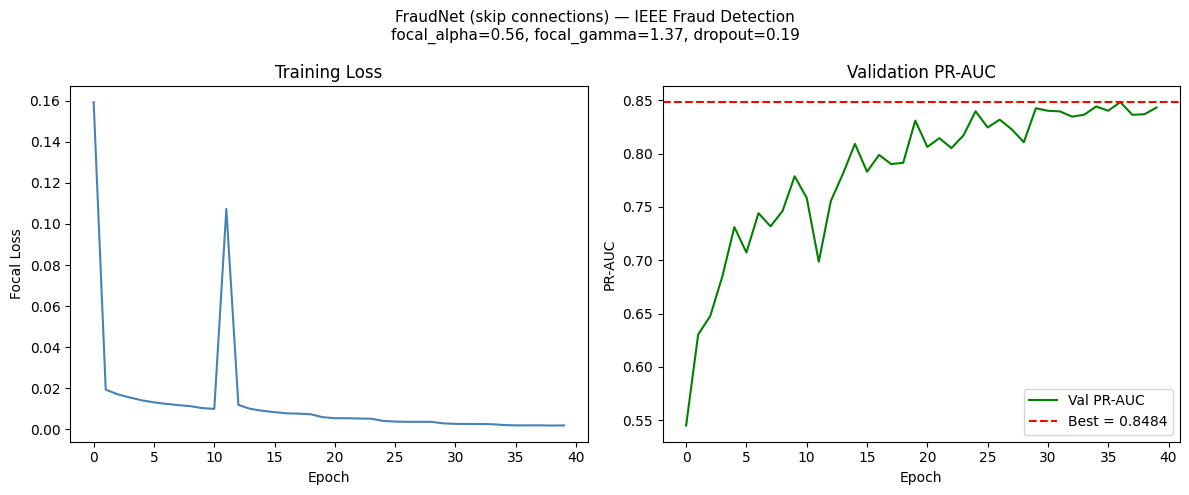

/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


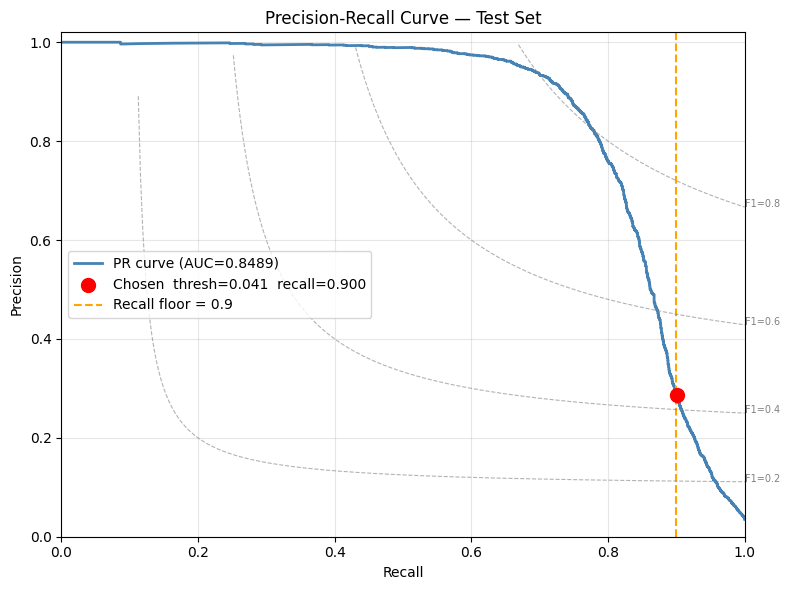

/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



  Final Results  (threshold = 0.041)
  Val  PR-AUC   : 0.8484
  Test PR-AUC   : 0.8489
  Test F-2.0    : 0.6310
  Test Recall   : 0.9003
  Test Precision: 0.2873
  Val  Recall   : 0.8964

Final metrics saved to runs/fraud_nn_high_recall/final_metrics.json
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.92      0.96     85482
       Fraud       0.29      0.90      0.44      3099

    accuracy                           0.92     88581
   macro avg       0.64      0.91      0.70     88581
weighted avg       0.97      0.92      0.94     88581


  All outputs saved to: runs/fraud_nn_high_recall/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt


In [3]:
"""
IEEE-CIS Fraud Detection — Neural Network (High-Recall + Skip Connections)
Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden blocks with SKIP CONNECTIONS (ResNet-style)
      Each block: Linear → BatchNorm → GELU → Dropout
      Skip: Linear projection if dims differ, identity if same
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - FocalLoss (NaN-safe, no pos_weight stacking)
      alpha tunes class imbalance, gamma focuses on hard examples
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
      focal_alpha and focal_gamma are tuned by Optuna
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC
  - Threshold selected by recall floor (MIN_RECALL) or F-beta (FBETA)

High-recall changes vs baseline
  [1] FocalLoss replaces BCEWithLogitsLoss — focuses on hard fraud examples
      pos_weight is NOT stacked inside FocalLoss (causes NaN); alpha handles
      class imbalance instead
  [2] POS_WEIGHT_MULTIPLIER removed from loss — kept only as a diagnostic print
  [3] Skip connections in FraudNet — preserve raw feature signal, stabilise
      training under aggressive focal loss
  [4] pick_threshold() — chooses threshold by recall floor first, then max
      precision; falls back to F-beta if floor is unreachable
  [5] MIN_RECALL / FBETA constants at top of file for easy tuning

NaN-prevention changes (fixes applied)
  [FIX-2] Tighter LR search range: 1e-4 → 3e-3 (was 1e-4 → 1e-2)
           High LRs with Lookahead+AdamW caused weight explosion on this arch.
  [FIX-3] train_epoch() now guards against NaN logits and NaN gradients:
           - If logits are NaN, re-initialises weights and skips the batch
           - If any gradient is NaN post-backward, skips the optimizer step
  [FIX-4] bayesian_search() objective wraps run_training() in try/except:
           ValueError and RuntimeError (including NaN loss) are caught and
           converted to optuna.TrialPruned so the study continues cleanly.
"""

import os
import json
import pickle
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Recall / threshold knobs ───────────────────────────────────────────────────
MIN_RECALL: float | None = 0.90   # tune: try 0.85, 0.90, 0.95
FBETA:      float        = 2.0    # beta > 1 → recall weighted more than precision


# ── Focal Loss (NaN-safe, no pos_weight) ──────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Binary Focal Loss — numerically stable.

    alpha : weight on the positive (fraud) class [0, 1].
            Higher alpha → stronger penalty for missing fraud.
            This replaces pos_weight; do NOT pass pos_weight here as well —
            stacking both causes gradient overflow → NaN.
    gamma : focusing exponent.  0 → standard BCE.  2 is a common default.
            Higher gamma → more focus on hard-to-classify examples.

    Optuna tunes both alpha (0.5–0.99) and gamma (0.5–4.0).
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )

        probs   = torch.sigmoid(logits)
        p_t     = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        focal_weight = alpha_t * (1 - p_t.clamp(min=1e-6)) ** self.gamma
        loss = (focal_weight * bce).mean()

        if torch.isnan(loss):
            raise ValueError(
                f"FocalLoss produced NaN. "
                f"logits range: [{logits.min():.2f}, {logits.max():.2f}], "
                f"alpha={self.alpha}, gamma={self.gamma}"
            )
        return loss


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k              = k
        self.alpha          = alpha
        self.param_groups   = base_optimizer.param_groups
        self.state          = base_optimizer.state
        self._step_counter  = 0
        self.slow_weights   = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter":   self._step_counter,
            "slow_weights":   [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y   = torch.tensor(df[target].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Skip block ─────────────────────────────────────────────────────────────────
class SkipBlock(nn.Module):
    """
    Residual block: out = dropout(gelu(bn(linear(x)))) + shortcut(x)

    If in_dim == out_dim  → identity shortcut (no extra parameters).
    If in_dim != out_dim  → 1×1 linear projection to match dimensions.
    """

    def __init__(self, in_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(p=dropout),
        )
        self.shortcut = (
            nn.Linear(in_dim, out_dim, bias=False)
            if in_dim != out_dim
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x) + self.shortcut(x)


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    """
    Embedding → concat → SkipBlock(H) → SkipBlock(H/2) → SkipBlock(H/4) → logit
    """

    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim   = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        self.block1 = SkipBlock(input_dim, h1, dropout)
        self.block2 = SkipBlock(h1,        h2, dropout)
        self.block3 = SkipBlock(h2,        h3, dropout)
        self.head   = nn.Linear(h3, 1)

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor:
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x    = torch.cat(embs + [num], dim=1)
        x    = self.block1(x)
        x    = self.block2(x)
        x    = self.block3(x)
        return self.head(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def get_pos_weight(y_series, device):
    """Compute neg/pos ratio (diagnostic only — NOT passed to FocalLoss)."""
    n_neg = (y_series == 0).sum()
    n_pos = (y_series == 1).sum()
    return torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)


def pick_threshold(
    precision_pts: np.ndarray,
    recall_pts:    np.ndarray,
    thresholds:    np.ndarray,
    min_recall:    float | None = MIN_RECALL,
    beta:          float        = FBETA,
) -> tuple[float, float, float, float]:
    """
    Choose the decision threshold.

    Strategy
    --------
    1. If min_recall is set, find all thresholds where recall >= min_recall.
       Among those, pick the one with the highest precision.
       If the floor is unreachable, warn and fall back to strategy 2.
    2. Otherwise maximise F-beta (beta > 1 weights recall over precision).

    Returns
    -------
    (threshold, f_beta_score, precision, recall)
    """
    prec   = precision_pts[:-1]
    rec    = recall_pts[:-1]
    thresh = thresholds

    if min_recall is not None:
        mask = rec >= min_recall
        if mask.any():
            candidates = np.where(mask)[0]
            best_idx   = candidates[np.argmax(prec[candidates])]
        else:
            print(
                f"  [WARN] Recall floor {min_recall} unreachable on this model. "
                f"Falling back to F-beta={beta} optimisation. "
                f"Try lowering MIN_RECALL or increasing focal_alpha."
            )
            fb       = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-8)
            best_idx = int(np.argmax(fb))
    else:
        fb       = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-8)
        best_idx = int(np.argmax(fb))

    fb_score = float(
        (1 + beta**2) * prec[best_idx] * rec[best_idx]
        / (beta**2 * prec[best_idx] + rec[best_idx] + 1e-8)
    )
    return float(thresh[best_idx]), fb_score, float(prec[best_idx]), float(rec[best_idx])


# ── FIX-3: NaN-guarded train_epoch ────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    """
    Train for one epoch with two NaN guards:

    Guard A — NaN logits:
        If the forward pass already produces NaN (model weights corrupted by a
        previous bad step), re-initialise weights with Xavier uniform and skip
        the batch.  This recovers gracefully rather than propagating NaN through
        the entire epoch.

    Guard B — NaN gradients:
        After loss.backward(), scan every parameter's .grad tensor.  If any
        gradient is NaN (can happen with extreme focal loss scaling even when
        logits are finite), skip the optimizer.step() so the corrupt update
        never lands.  The zero_grad() at the top of the next iteration clears
        the bad gradients automatically.
    """
    model.train()
    total_loss    = 0.0
    skipped_nan   = 0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(cat, num)

        # Guard A: NaN logits → weights already blown up; re-init and skip
        if torch.isnan(logits).any():
            skipped_nan += 1
            print(
                f"  [WARN] NaN logits detected (batch skipped #{skipped_nan}). "
                f"Re-initialising model weights."
            )
            model._xavier_init()
            continue

        loss = criterion(logits, y)
        loss.backward()

        # Guard B: NaN gradients → skip optimizer step, don't corrupt weights
        has_nan_grad = any(
            p.grad is not None and torch.isnan(p.grad).any()
            for p in model.parameters()
        )
        if has_nan_grad:
            skipped_nan += 1
            print(
                f"  [WARN] NaN gradient detected (step skipped #{skipped_nan}). "
                f"Zeroing grads and continuing."
            )
            optimizer.zero_grad()
            continue

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)

    if skipped_nan:
        print(f"  [INFO] Epoch had {skipped_nan} skipped batch(es) due to NaN.")

    return total_loss / max(len(loader.dataset) - skipped_nan * loader.batch_size, 1)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        probs = model.predict_proba(cat, num).cpu().numpy()

        if np.isnan(probs).any():
            raise ValueError(
                f"Model output contains NaN probabilities. "
                f"Check loss function and learning rate. "
                f"NaN count: {np.isnan(probs).sum()}/{len(probs)}"
            )

        all_p.extend(probs)
        all_y.extend(y.numpy())
    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []
    if device is None:
        device = next(model.parameters()).device
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        all_p.extend(model.predict_proba(cat, num).cpu().numpy())
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_p)


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch":             epoch,
        "val_pr_auc":        val_pr,
        "config":            config,
        "model_state_dict":  model.state_dict(),
        "optimizer_state":   optimizer.state_dict(),
        "cat_cols":          metadata["cat_cols"],
        "num_cols":          metadata["num_cols"],
        "vocab_sizes":       metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    pos_weight,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    loader_tr = DataLoader(
        train_ds, batch_size=config["batch_size"],
        shuffle=True,  num_workers=0, pin_memory=True,
    )
    loader_va = DataLoader(
        val_ds, batch_size=config["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt, mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )

    criterion = FocalLoss(
        alpha=config["focal_alpha"],
        gamma=config["focal_gamma"],
    )

    history = {"train_loss": [], "val_pr": []}
    best_state, best_val_pr_auc = None, 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")
    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0         = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr     = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)
        elapsed    = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model, optimizer, epoch, val_pr, config, metadata,
                )
        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model, optimizer, epoch, val_pr, config, metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")
        epoch_log_rows.append({
            "epoch": epoch, "train_loss": train_loss,
            "val_pr": val_pr, "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"), index=False)

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
    pos_weight, metadata, device, n_trials=30, n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim":     trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            # FIX-2: upper LR bound reduced from 1e-2 to 3e-3.
            # High LRs (>3e-3) caused weight explosion with Lookahead+AdamW
            # on skip-connection architectures, producing NaN logits within
            # the first few batches. The useful search space is well within
            # [1e-4, 3e-3]; trials above that almost never survived pruning.
            "lr":             trial.suggest_float("lr", 1e-4, 3e-3, log=True),
            "weight_decay":   trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size":     trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k":           trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha":       trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor":   trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout":        trial.suggest_float("dropout", 0.1, 0.5),
            "focal_alpha":    trial.suggest_float("focal_alpha", 0.5, 0.99),
            "focal_gamma":    trial.suggest_float("focal_gamma", 0.5, 4.0),
        }

        # FIX-4: catch NaN / RuntimeError from training and convert to a pruned
        # trial so the study continues rather than raising to the caller.
        # ValueError covers FocalLoss NaN and eval_pr_auc NaN detection.
        # RuntimeError covers CUDA/MPS numerical errors (e.g. inf in softmax).
        try:
            val_pr, _, _ = run_training(
                config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
                pos_weight, metadata, device,
                run_dir=None, n_epochs=n_epochs_tune, trial=trial,
            )
            return val_pr
        except (ValueError, RuntimeError) as e:
            print(
                f"  [Trial {trial.number}] Failed with {type(e).__name__}: {e} "
                f"— converting to pruned trial."
            )
            raise optuna.exceptions.TrialPruned()

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )
    study.optimize(
        objective,
        n_trials=n_trials,
        callbacks=[lambda s, t: print(
            f"  [Trial {t.number:>2}] val_PR-AUC="
            f"{(t.value if t.value is not None else float('nan')):.4f}"
            f"  params={t.params}"
        )],
    )
    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Confusion matrix ───────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)
    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    run_dir = os.path.join("runs", "fraud_nn_high_recall")
    n_epochs_full = 40
    os.makedirs(run_dir, exist_ok=True)

    print(f"Device         : {device}")
    print(f"Run dir        : {run_dir}/")
    print(f"Recall target  : {MIN_RECALL}")
    print(f"F-beta         : {FBETA}")

    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df   = pd.read_csv("preprocessed/val.csv")
    test_df  = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target      = metadata["target"]
    cat_cols    = [c for c in metadata["cat_cols"]  if c in train_df.columns]
    num_cols    = [c for c in metadata["num_cols"]  if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds   = FraudDataset(val_df,   cat_cols, num_cols, target)
    test_ds  = FraudDataset(test_df,  cat_cols, num_cols, target)

    pos_weight = get_pos_weight(train_df[target], device)
    print(f"neg/pos ratio  : {pos_weight.item():.2f}  (diagnostic only — handled by focal_alpha)")

    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        pos_weight, metadata, device, n_trials=30, n_epochs_tune=8,
    )
    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"), index=False)

    best_config = {k: best_params[k] for k in [
        "hidden_dim", "lr", "weight_decay", "batch_size",
        "la_k", "la_alpha", "sched_patience", "sched_factor",
        "dropout", "focal_alpha", "focal_gamma",
    ]}

    print(f"\n{'='*60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"{'='*60}\n")

    loader_train = DataLoader(
        train_ds, batch_size=best_config["batch_size"],
        shuffle=True,  num_workers=0, pin_memory=True)
    loader_val = DataLoader(
        val_ds,   batch_size=best_config["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True)
    loader_test = DataLoader(
        test_ds,  batch_size=best_config["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True)

    best_val_pr_auc, best_state, history = run_training(
        best_config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        pos_weight, metadata, device, run_dir=run_dir, n_epochs=n_epochs_full,
    )

    model = FraudNet(
        cat_cols=cat_cols, vocab_sizes=vocab_sizes,
        num_dim=len(num_cols), hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)
    model.load_state_dict(best_state)

    val_pr  = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    # ── Training curves ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history["train_loss"], color="steelblue")
    axes[0].set(xlabel="Epoch", ylabel="Focal Loss", title="Training Loss")

    axes[1].plot(history["val_pr"], color="green", label="Val PR-AUC")
    axes[1].axhline(best_val_pr_auc, color="red", linestyle="--",
                    label=f"Best = {best_val_pr_auc:.4f}")
    axes[1].set(xlabel="Epoch", ylabel="PR-AUC", title="Validation PR-AUC")
    axes[1].legend()

    plt.suptitle(
        f"FraudNet (skip connections) — IEEE Fraud Detection\n"
        f"focal_alpha={best_config['focal_alpha']:.2f}, "
        f"focal_gamma={best_config['focal_gamma']:.2f}, "
        f"dropout={best_config['dropout']:.2f}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "nn_training_curves.png"), dpi=150)
    plt.show()

    # ── Threshold selection ────────────────────────────────────────────────────
    y_true, y_proba = get_predictions(model, loader_test)
    precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

    best_thresh, best_fb, best_precision, best_recall = pick_threshold(
        precision_pts, recall_pts, thresholds)

    # ── PR curve ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_pts, precision_pts, color="steelblue", lw=2,
            label=f"PR curve (AUC={test_pr:.4f})")
    ax.scatter(best_recall, best_precision, color="red", zorder=5, s=100,
               label=f"Chosen  thresh={best_thresh:.3f}  recall={best_recall:.3f}")

    if MIN_RECALL is not None:
        ax.axvline(MIN_RECALL, color="orange", linestyle="--",
                   label=f"Recall floor = {MIN_RECALL}")

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask   = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(f"F1={f1_iso}",
                    xy=(r_vals[mask][-1], p_vals[mask][-1]),
                    fontsize=7, color="grey")

    ax.set(xlabel="Recall", ylabel="Precision",
           title="Precision-Recall Curve — Test Set",
           xlim=[0, 1], ylim=[0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "pr_curve.png"), dpi=150)
    plt.show()

    # ── Val recall at chosen threshold ─────────────────────────────────────────
    val_y_true, val_proba = get_predictions(model, loader_val)
    val_recall = recall_score(
        val_y_true, (val_proba >= best_thresh).astype(int), zero_division=0)

    print(f"\n{'='*50}")
    print(f"  Final Results  (threshold = {best_thresh:.3f})")
    print(f"{'='*50}")
    print(f"  Val  PR-AUC   : {val_pr:.4f}")
    print(f"  Test PR-AUC   : {test_pr:.4f}")
    print(f"  Test F-{FBETA}    : {best_fb:.4f}")
    print(f"  Test Recall   : {best_recall:.4f}")
    print(f"  Test Precision: {best_precision:.4f}")
    print(f"  Val  Recall   : {val_recall:.4f}")

    final_metrics = {
        "best_config":          best_config,
        "val_pr_auc":           val_pr,
        "test_pr_auc":          test_pr,
        "best_thresh":          best_thresh,
        "test_fbeta":           best_fb,
        "beta":                 FBETA,
        "test_recall":          best_recall,
        "test_precision":       best_precision,
        "val_recall":           val_recall,
        "min_recall_target":    MIN_RECALL,
    }
    with open(os.path.join(run_dir, "final_metrics.json"), "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {os.path.join(run_dir, 'final_metrics.json')}")

    plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

    torch.save({
        "model_state_dict": best_state,
        "best_config":      best_config,
        "val_pr_auc":       val_pr,
        "test_pr_auc":      test_pr,
        "best_thresh":      best_thresh,
        "test_recall":      best_recall,
        "val_recall":       val_recall,
        "cat_cols":         cat_cols,
        "num_cols":         num_cols,
        "vocab_sizes":      vocab_sizes,
    }, os.path.join(run_dir, "nn_model.pt"))

    print(f"\n{'='*50}")
    print(f"  All outputs saved to: {run_dir}/")
    print(f"    nn_training_curves.png")
    print(f"    pr_curve.png")
    print(f"    confusion_matrix.png")
    print(f"    classification_report.txt")
    print(f"    training_log.csv")
    print(f"    hp_search_results.csv")
    print(f"    final_metrics.json")
    print(f"    nn_model.pt")
    print(f"{'='*50}")


if __name__ == "__main__":
    main()

## Chatgpt -> update this model - Final Results at validation-selected threshold = 0.305

Your original model already did this:
train a fraud classifier
output fraud probabilities
pick one threshold using validation F2
evaluate on test
The updated version keeps that, but adds tools to answer:
Which threshold is best if I care about recall?
Which threshold is best if I care about business cost?
Are my probabilities well calibrated or just good for ranking?
Should I use 3 decisions instead of just fraud / non-fraud?
Can I add a second filter to reduce false positives?


In [4]:
"""
IEEE-CIS Fraud Detection — Neural Network (Extended)

Architecture:
  - Individual embedding per categorical column
  - Scaled numerical features (done in preprocessing)
  - 3 hidden layers: H → H/2 → H/4, each: Linear → BatchNorm → GELU
  - Xavier uniform init, zero bias
  - Lookahead(AdamW) optimiser
  - Alpha-balanced FocalLoss (alpha + gamma tuned by Optuna)
  - L2 regularisation via AdamW weight_decay
  - Dropout (tuned by Optuna, range 0.1–0.5) after each hidden block
  - ReduceLROnPlateau scheduler (mode=max, tracks val PR-AUC)
  - Bayesian hyperparameter search via Optuna (TPE sampler)
  - Mini-batch training via DataLoader
  - Gradient clipping (max_norm=1.0)
  - Saves best.pt and last.pt
  - Main metric: PR-AUC

Extensions added:
  - Threshold sweep analysis
  - Threshold chosen by minimum recall constraint
  - Threshold chosen by business cost
  - Probability calibration
  - 3-way decision system (accept / review / decline)
  - Optional stage-2 filter on flagged cases
"""

import os
import json
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Alpha-balanced binary focal loss on raw logits.

    alpha:
        weight for positive class (fraud)
        higher alpha -> more emphasis on fraud examples

    gamma:
        focusing parameter; 0.0 => BCE
    """

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_weight = alpha_t * (1.0 - p_t).pow(self.gamma)

        loss = focal_weight * bce
        return loss.mean()


# ── Lookahead ──────────────────────────────────────────────────────────────────
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups
        self.state = base_optimizer.state
        self._step_counter = 0
        self.slow_weights = [
            [p.clone().detach() for p in group["params"]]
            for group in self.param_groups
        ]

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_counter += 1
        if self._step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow_p in zip(group["params"], slow_group):
                    if p.grad is None:
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data))
                    p.data.copy_(slow_p.data)
        return loss

    def zero_grad(self, set_to_none=False):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self):
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state):
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]


# ── Dataset ────────────────────────────────────────────────────────────────────
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]


# ── Model ──────────────────────────────────────────────────────────────────────
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, hidden_dim, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])

        emb_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            block(input_dim, h1),
            block(h1, h2),
            block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat, num):
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat, num):
        return torch.sigmoid(self.forward(cat, num))


# ── Utilities ──────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for cat, num, y in loader:
        cat, num, y = cat.to(device), num.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(cat, num)
        if not torch.isfinite(logits).all():
            raise ValueError("Non-finite logits encountered during training.")

        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            raise ValueError("Non-finite loss encountered during training.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_pr_auc(model, loader, device):
    model.eval()
    all_p, all_y = [], []

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered during evaluation.")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return average_precision_score(np.array(all_y), np.array(all_p))


def evaluate_metrics(model, loader):
    return eval_pr_auc(model, loader, next(model.parameters()).device)


@torch.no_grad()
def get_predictions(model, loader, device=None):
    model.eval()
    all_p, all_y = [], []

    if device is None:
        device = next(model.parameters()).device

    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()

        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered in get_predictions().")

        all_p.extend(proba)
        all_y.extend(y.numpy())

    return np.array(all_y), np.array(all_p)


def find_best_fbeta_threshold(y_true, y_proba, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0

    beta2 = beta ** 2
    scores = (
        (1 + beta2) * precision[:-1] * recall[:-1]
        / (beta2 * precision[:-1] + recall[:-1] + 1e-8)
    )

    best_idx = int(np.argmax(scores))
    return (
        float(thresholds[best_idx]),
        float(scores[best_idx]),
        float(recall[best_idx]),
        float(precision[best_idx]),
    )


# ── New: Threshold sweep / analysis ────────────────────────────────────────────
def sweep_thresholds(y_true, y_proba, beta=2.0, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        fbeta = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        rows.append({
            "threshold": float(th),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "fbeta": float(fbeta),
            "tp": int(tp),
            "fp": int(fp),
            "tn": int(tn),
            "fn": int(fn),
            "predicted_positive_rate": float((y_pred == 1).mean()),
        })

    return pd.DataFrame(rows)


def choose_threshold_by_min_recall(y_true, y_proba, min_recall=0.90, beta=2.0):
    df = sweep_thresholds(y_true, y_proba, beta=beta)

    eligible = df[df["recall"] >= min_recall].copy()

    if len(eligible) > 0:
        best_row = eligible.sort_values(
            ["fbeta", "precision", "threshold"],
            ascending=[False, False, False]
        ).iloc[0]
    else:
        best_row = df.sort_values(
            ["recall", "precision"],
            ascending=[False, False]
        ).iloc[0]

    return best_row.to_dict()


def choose_threshold_by_cost(
    y_true,
    y_proba,
    fp_cost=1.0,
    fn_cost=10.0,
    thresholds=None,
):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    best = None
    best_cost = float("inf")

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        total_cost = fp_cost * fp + fn_cost * fn

        row = {
            "threshold": float(th),
            "cost": float(total_cost),
            "tp": int(tp),
            "fp": int(fp),
            "tn": int(tn),
            "fn": int(fn),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        }

        if total_cost < best_cost:
            best_cost = total_cost
            best = row

    return best


# ── New: 3-way decision system ────────────────────────────────────────────────
def apply_three_way_decision(y_proba, low_thresh, high_thresh):
    """
    0 -> accept / non-fraud
    1 -> review
    2 -> decline / fraud
    """
    decision = np.zeros(len(y_proba), dtype=int)
    decision[(y_proba >= low_thresh) & (y_proba < high_thresh)] = 1
    decision[y_proba >= high_thresh] = 2
    return decision


def evaluate_three_way_system(y_true, y_proba, low_thresh, high_thresh):
    decision = apply_three_way_decision(y_proba, low_thresh, high_thresh)

    auto_accept_mask = decision == 0
    review_mask = decision == 1
    decline_mask = decision == 2
    flagged_mask = review_mask | decline_mask

    fraud_capture = ((flagged_mask) & (y_true == 1)).sum() / max((y_true == 1).sum(), 1)

    if decline_mask.sum() > 0:
        decline_precision = y_true[decline_mask].mean()
    else:
        decline_precision = 0.0

    hard_decline_recall = ((decline_mask) & (y_true == 1)).sum() / max((y_true == 1).sum(), 1)

    return {
        "low_thresh": float(low_thresh),
        "high_thresh": float(high_thresh),
        "auto_accept_count": int(auto_accept_mask.sum()),
        "review_count": int(review_mask.sum()),
        "auto_decline_count": int(decline_mask.sum()),
        "review_rate": float(review_mask.mean()),
        "auto_decline_rate": float(decline_mask.mean()),
        "fraud_capture_review_or_decline": float(fraud_capture),
        "decline_precision": float(decline_precision),
        "hard_decline_recall": float(hard_decline_recall),
    }


# ── New: Calibration ───────────────────────────────────────────────────────────
def fit_isotonic_calibrator(y_true, y_proba):
    calibrator = IsotonicRegression(out_of_bounds="clip")
    calibrator.fit(y_proba, y_true)
    return calibrator


def apply_isotonic_calibrator(calibrator, y_proba):
    return np.asarray(calibrator.predict(y_proba), dtype=float)


# ── New: Stage-2 filter (optional) ────────────────────────────────────────────
def train_stage2_filter(
    train_features_df,
    train_y,
    test_features_df,
    test_y,
    feature_cols,
):
    """
    Simple second-stage classifier for flagged cases only.
    Uses LogisticRegression on already-preprocessed features.

    Note:
    - This is optional.
    - Best used on a separate flagged-train split in a real setup.
    """
    clf = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42,
    )
    clf.fit(train_features_df[feature_cols], train_y)

    test_proba = clf.predict_proba(test_features_df[feature_cols])[:, 1]
    return clf, test_proba


# ── Checkpointing ──────────────────────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, epoch, val_pr, config, metadata):
    torch.save({
        "epoch": epoch,
        "val_pr_auc": val_pr,
        "config": config,
        "model_state_dict": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "cat_cols": metadata["cat_cols"],
        "num_cols": metadata["num_cols"],
        "vocab_sizes": metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")


def load_checkpoint(path, model, optimizer=None, device="cuda"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt


# ── Training run ───────────────────────────────────────────────────────────────
def run_training(
    config,
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    run_dir=None,
    n_epochs=40,
    trial=None,
):
    use_pin_memory = (device.type == "cuda")

    loader_tr = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_va = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )
    criterion = FocalLoss(alpha=config["alpha"], gamma=config["gamma"])

    history = {"train_loss": [], "val_pr": []}
    best_state = None
    best_val_pr_auc = 0.0

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device)
        val_pr = eval_pr_auc(model, loader_va, device)
        scheduler.step(val_pr)

        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_pr"].append(val_pr)

        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model,
                    optimizer,
                    epoch,
                    val_pr,
                    config,
                    metadata,
                )

        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model,
                optimizer,
                epoch,
                val_pr,
                config,
                metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_pr": val_pr,
            "time_s": round(elapsed, 1),
        })

        if trial is not None:
            trial.report(val_pr, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    if run_dir:
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history


# ── Bayesian search ────────────────────────────────────────────────────────────
def bayesian_search(
    train_ds,
    val_ds,
    vocab_sizes,
    cat_cols,
    num_cols,
    metadata,
    device,
    n_trials=30,
    n_epochs_tune=8,
):
    def objective(trial):
        config = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 512]),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 4096]),
            "la_k": trial.suggest_categorical("la_k", [5, 10]),
            "la_alpha": trial.suggest_float("la_alpha", 0.3, 0.8),
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]),
            "sched_factor": trial.suggest_float("sched_factor", 0.3, 0.7),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "alpha": trial.suggest_float("alpha", 0.60, 0.95),
            "gamma": trial.suggest_float("gamma", 0.5, 5.0),
        }

        val_pr, _, _ = run_training(
            config,
            train_ds,
            val_ds,
            vocab_sizes,
            cat_cols,
            num_cols,
            metadata,
            device,
            run_dir=None,
            n_epochs=n_epochs_tune,
            trial=trial,
        )
        return val_pr

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        catch=(ValueError,),
        callbacks=[
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study


# ── Plots ──────────────────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_proba, threshold, run_dir, filename="confusion_matrix.png"):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        ax=axes[1],
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
    )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, filename), dpi=150)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)

    txt_name = filename.replace(".png", "_report.txt")
    with open(os.path.join(run_dir, txt_name), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")


def plot_threshold_metrics(df_thresh, run_dir, beta=2.0, filename="threshold_sweep.png"):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(df_thresh["threshold"], df_thresh["precision"], label="Precision")
    ax.plot(df_thresh["threshold"], df_thresh["recall"], label="Recall")
    ax.plot(df_thresh["threshold"], df_thresh["f1"], label="F1")
    ax.plot(df_thresh["threshold"], df_thresh["fbeta"], label=f"F{beta}")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.set_title("Threshold Sweep Metrics")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    path = os.path.join(run_dir, filename)
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Threshold sweep plot saved to {path}")


def plot_probability_histograms(y_true, y_proba, run_dir, filename="probability_histograms.png"):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(y_proba[y_true == 0], bins=50, alpha=0.6, label="Non-Fraud", density=True)
    ax.hist(y_proba[y_true == 1], bins=50, alpha=0.6, label="Fraud", density=True)

    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.set_title("Predicted Probability Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(run_dir, filename)
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Probability histogram saved to {path}")


def plot_pr_curve(y_true, y_proba, pr_auc, threshold, point_label, run_dir, filename="pr_curve.png"):
    y_pred = (y_proba >= threshold).astype(int)
    test_recall = recall_score(y_true, y_pred, zero_division=0)
    test_precision = precision_score(y_true, y_pred, zero_division=0)

    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        recall_pts,
        precision_pts,
        color="steelblue",
        lw=2,
        label=f"PR curve (AUC = {pr_auc:.4f})",
    )
    ax.scatter(
        test_recall,
        test_precision,
        color="red",
        zorder=5,
        s=100,
        label=f"{point_label} thresh={threshold:.3f}",
    )

    for f1_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 300)
        p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
        ax.annotate(
            f"F1={f1_iso}",
            xy=(r_vals[mask][-1], p_vals[mask][-1]),
            fontsize=7,
            color="grey",
        )

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(run_dir, filename)
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"PR curve saved to {path}")


# ── Main ───────────────────────────────────────────────────────────────────────
def main():
    # ============================================================
    # SETTINGS
    # ============================================================
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    run_dir = os.path.join("runs", "fraud_nn_extended")
    n_epochs_full = 40
    beta_for_threshold = 2.0

    # New settings
    min_recall_target = 0.90
    fp_cost = 1.0
    fn_cost = 10.0
    run_stage2 = False   # Set True if you want optional stage-2 filtering

    os.makedirs(run_dir, exist_ok=True)

    print(f"Device  : {device}")
    print(f"Run dir : {run_dir}/")

    # ============================================================
    # LOAD DATA
    # ============================================================
    print("\nLoading preprocessed data...")
    train_df = pd.read_csv("preprocessed/train.csv")
    val_df = pd.read_csv("preprocessed/val.csv")
    test_df = pd.read_csv("preprocessed/test.csv")

    with open("preprocessed/column_metadata.pkl", "rb") as f:
        metadata = pickle.load(f)

    target = metadata["target"]
    cat_cols = [c for c in metadata["cat_cols"] if c in train_df.columns]
    num_cols = [c for c in metadata["num_cols"] if c in train_df.columns]
    vocab_sizes = metadata["vocab_sizes"]

    print(f"Categorical : {len(cat_cols)}")
    print(f"Numerical   : {len(num_cols)}")

    fraud_rate = train_df[target].mean()
    print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

    train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
    val_ds = FraudDataset(val_df, cat_cols, num_cols, target)
    test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

    # ============================================================
    # TUNING
    # ============================================================
    print("\n" + "=" * 60)
    print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
    print("=" * 60)

    best_params, study = bayesian_search(
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        n_trials=30,
        n_epochs_tune=8,
    )

    study.trials_dataframe().to_csv(
        os.path.join(run_dir, "hp_search_results.csv"),
        index=False,
    )

    best_config = {
        k: best_params[k]
        for k in [
            "hidden_dim",
            "lr",
            "weight_decay",
            "batch_size",
            "la_k",
            "la_alpha",
            "sched_patience",
            "sched_factor",
            "dropout",
            "alpha",
            "gamma",
        ]
    }

    print(f"\n{'=' * 60}")
    print(f"Full training for {n_epochs_full} epochs with best config")
    print(f"  alpha = {best_config['alpha']:.3f}")
    print(f"  gamma = {best_config['gamma']:.3f}")
    print(f"{'=' * 60}\n")

    # ============================================================
    # FULL TRAINING
    # ============================================================
    use_pin_memory = (device.type == "cuda")
    batch_size = best_config["batch_size"]

    loader_val = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )
    loader_test = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    best_val_pr_auc, best_state, history = run_training(
        best_config,
        train_ds,
        val_ds,
        vocab_sizes,
        cat_cols,
        num_cols,
        metadata,
        device,
        run_dir=run_dir,
        n_epochs=n_epochs_full,
    )

    if best_state is None:
        raise RuntimeError("Training failed: no valid checkpoint was produced.")

    model = FraudNet(
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=best_config["hidden_dim"],
        dropout=best_config["dropout"],
    ).to(device)

    model.load_state_dict(best_state)

    val_pr = evaluate_metrics(model, loader_val)
    test_pr = evaluate_metrics(model, loader_test)

    print(f"\n{'=' * 50}")
    print(f"  Checkpoint PR-AUC")
    print(f"{'=' * 50}")
    print(f"  Val  PR-AUC : {val_pr:.4f}")
    print(f"  Test PR-AUC : {test_pr:.4f}")

    # ============================================================
    # TRAINING CURVES
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Focal Loss")
    axes[0].set_title("Training Loss")
    axes[0].legend()

    axes[1].plot(history["val_pr"], label="Val PR-AUC", color="green")
    axes[1].axhline(y=best_val_pr_auc, color="red", linestyle="--", label=f"Best = {best_val_pr_auc:.4f}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PR-AUC")
    axes[1].set_title("Validation PR-AUC over Training")
    axes[1].legend()

    cfg_label = (
        f"lr={best_config['lr']:.4f}, dropout={best_config['dropout']:.2f}, "
        f"bs={best_config['batch_size']}, alpha={best_config['alpha']:.2f}, "
        f"gamma={best_config['gamma']:.2f}"
    )
    plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
    plt.tight_layout()
    curves_path = os.path.join(run_dir, "nn_training_curves.png")
    plt.savefig(curves_path, dpi=150)
    plt.close()
    print(f"Training curves saved to {curves_path}")

    # ============================================================
    # RAW PREDICTIONS
    # ============================================================
    val_y_true, val_proba = get_predictions(model, loader_val)
    test_y_true, test_proba = get_predictions(model, loader_test)

    plot_probability_histograms(test_y_true, test_proba, run_dir, "probability_histograms_raw.png")

    # ============================================================
    # THRESHOLD 1: VALIDATION F2
    # ============================================================
    f2_thresh, val_best_f2, val_best_recall, val_best_precision = find_best_fbeta_threshold(
        val_y_true,
        val_proba,
        beta=beta_for_threshold,
    )

    test_pred_f2 = (test_proba >= f2_thresh).astype(int)
    test_f2_recall = recall_score(test_y_true, test_pred_f2, zero_division=0)
    test_f2_precision = precision_score(test_y_true, test_pred_f2, zero_division=0)
    test_f2_f1 = f1_score(test_y_true, test_pred_f2, zero_division=0)
    test_f2_f2 = fbeta_score(test_y_true, test_pred_f2, beta=beta_for_threshold, zero_division=0)

    # ============================================================
    # THRESHOLD 2: MINIMUM RECALL
    # ============================================================
    min_recall_choice = choose_threshold_by_min_recall(
        val_y_true,
        val_proba,
        min_recall=min_recall_target,
        beta=beta_for_threshold,
    )
    min_recall_thresh = float(min_recall_choice["threshold"])

    test_pred_minrec = (test_proba >= min_recall_thresh).astype(int)
    test_minrec_recall = recall_score(test_y_true, test_pred_minrec, zero_division=0)
    test_minrec_precision = precision_score(test_y_true, test_pred_minrec, zero_division=0)
    test_minrec_f1 = f1_score(test_y_true, test_pred_minrec, zero_division=0)
    test_minrec_f2 = fbeta_score(test_y_true, test_pred_minrec, beta=beta_for_threshold, zero_division=0)

    # ============================================================
    # THRESHOLD 3: COST-BASED
    # ============================================================
    cost_choice = choose_threshold_by_cost(
        val_y_true,
        val_proba,
        fp_cost=fp_cost,
        fn_cost=fn_cost,
    )
    cost_thresh = float(cost_choice["threshold"])

    test_pred_cost = (test_proba >= cost_thresh).astype(int)
    test_cost_recall = recall_score(test_y_true, test_pred_cost, zero_division=0)
    test_cost_precision = precision_score(test_y_true, test_pred_cost, zero_division=0)
    test_cost_f1 = f1_score(test_y_true, test_pred_cost, zero_division=0)
    test_cost_f2 = fbeta_score(test_y_true, test_pred_cost, beta=beta_for_threshold, zero_division=0)

    # ============================================================
    # THRESHOLD SWEEP OUTPUTS
    # ============================================================
    df_thresh_val = sweep_thresholds(val_y_true, val_proba, beta=beta_for_threshold)
    df_thresh_test = sweep_thresholds(test_y_true, test_proba, beta=beta_for_threshold)

    df_thresh_val.to_csv(os.path.join(run_dir, "threshold_sweep_val.csv"), index=False)
    df_thresh_test.to_csv(os.path.join(run_dir, "threshold_sweep_test.csv"), index=False)

    plot_threshold_metrics(df_thresh_val, run_dir, beta=beta_for_threshold, filename="threshold_sweep_val.png")
    plot_threshold_metrics(df_thresh_test, run_dir, beta=beta_for_threshold, filename="threshold_sweep_test.png")

    # ============================================================
    # RAW PR CURVE
    # ============================================================
    plot_pr_curve(
        test_y_true,
        test_proba,
        test_pr,
        f2_thresh,
        point_label=f"F2={test_f2_f2:.4f}",
        run_dir=run_dir,
        filename="pr_curve_raw.png",
    )

    # ============================================================
    # CALIBRATION
    # ============================================================
    calibrator = fit_isotonic_calibrator(val_y_true, val_proba)
    val_proba_cal = apply_isotonic_calibrator(calibrator, val_proba)
    test_proba_cal = apply_isotonic_calibrator(calibrator, test_proba)

    val_pr_cal = average_precision_score(val_y_true, val_proba_cal)
    test_pr_cal = average_precision_score(test_y_true, test_proba_cal)

    plot_probability_histograms(test_y_true, test_proba_cal, run_dir, "probability_histograms_calibrated.png")

    cal_f2_thresh, cal_val_best_f2, cal_val_best_recall, cal_val_best_precision = find_best_fbeta_threshold(
        val_y_true,
        val_proba_cal,
        beta=beta_for_threshold,
    )

    test_pred_cal = (test_proba_cal >= cal_f2_thresh).astype(int)
    test_cal_recall = recall_score(test_y_true, test_pred_cal, zero_division=0)
    test_cal_precision = precision_score(test_y_true, test_pred_cal, zero_division=0)
    test_cal_f1 = f1_score(test_y_true, test_pred_cal, zero_division=0)
    test_cal_f2 = fbeta_score(test_y_true, test_pred_cal, beta=beta_for_threshold, zero_division=0)

    plot_pr_curve(
        test_y_true,
        test_proba_cal,
        test_pr_cal,
        cal_f2_thresh,
        point_label=f"Cal-F2={test_cal_f2:.4f}",
        run_dir=run_dir,
        filename="pr_curve_calibrated.png",
    )

    # ============================================================
    # 3-WAY DECISION SYSTEM
    # low = F2 threshold
    # high = cost-based threshold if higher, else use a stricter fallback
    # ============================================================
    high_thresh = max(cost_thresh, f2_thresh + 0.10)
    high_thresh = min(high_thresh, 0.99)

    three_way_metrics = evaluate_three_way_system(
        test_y_true,
        test_proba_cal,
        low_thresh=cal_f2_thresh,
        high_thresh=high_thresh,
    )

    with open(os.path.join(run_dir, "three_way_metrics.json"), "w") as f:
        json.dump(three_way_metrics, f, indent=2)

    # ============================================================
    # OPTIONAL STAGE-2 FILTER
    # ============================================================
    stage2_results = None
    if run_stage2:
        print("\nRunning optional stage-2 filter...")

        flagged_val_mask = val_proba_cal >= cal_f2_thresh
        flagged_test_mask = test_proba_cal >= cal_f2_thresh

        feature_cols_stage2 = cat_cols + num_cols

        val_stage2_df = val_df.loc[flagged_val_mask, feature_cols_stage2].copy()
        test_stage2_df = test_df.loc[flagged_test_mask, feature_cols_stage2].copy()

        y_val_stage2 = val_df.loc[flagged_val_mask, target].values
        y_test_stage2 = test_df.loc[flagged_test_mask, target].values

        if len(val_stage2_df) > 50 and len(np.unique(y_val_stage2)) > 1:
            stage2_model, stage2_test_proba = train_stage2_filter(
                val_stage2_df,
                y_val_stage2,
                test_stage2_df,
                y_test_stage2,
                feature_cols_stage2,
            )

            stage2_pr = average_precision_score(y_test_stage2, stage2_test_proba)
            stage2_thresh, _, _, _ = find_best_fbeta_threshold(
                y_val_stage2,
                stage2_model.predict_proba(val_stage2_df[feature_cols_stage2])[:, 1],
                beta=beta_for_threshold,
            )
            stage2_pred = (stage2_test_proba >= stage2_thresh).astype(int)

            stage2_results = {
                "flagged_val_count": int(len(val_stage2_df)),
                "flagged_test_count": int(len(test_stage2_df)),
                "test_pr_auc": float(stage2_pr),
                "threshold": float(stage2_thresh),
                "test_recall": float(recall_score(y_test_stage2, stage2_pred, zero_division=0)),
                "test_precision": float(precision_score(y_test_stage2, stage2_pred, zero_division=0)),
                "test_f1": float(f1_score(y_test_stage2, stage2_pred, zero_division=0)),
            }

            with open(os.path.join(run_dir, "stage2_results.json"), "w") as f:
                json.dump(stage2_results, f, indent=2)
        else:
            stage2_results = {"status": "Skipped: not enough flagged validation cases or only one class."}
            with open(os.path.join(run_dir, "stage2_results.json"), "w") as f:
                json.dump(stage2_results, f, indent=2)

    # ============================================================
    # SAVE METRICS SUMMARY
    # ============================================================
    final_metrics = {
        "best_config": {
            "lr": best_config["lr"],
            "batch_size": best_config["batch_size"],
            "hidden_dim": best_config["hidden_dim"],
            "weight_decay": best_config["weight_decay"],
            "la_k": best_config["la_k"],
            "la_alpha": best_config["la_alpha"],
            "sched_patience": best_config["sched_patience"],
            "sched_factor": best_config["sched_factor"],
            "dropout": best_config["dropout"],
            "alpha": best_config["alpha"],
            "gamma": best_config["gamma"],
        },
        "raw_model": {
            "val_pr_auc": float(val_pr),
            "test_pr_auc": float(test_pr),
        },
        "thresholds": {
            "f2_threshold": float(f2_thresh),
            "min_recall_threshold": float(min_recall_thresh),
            "cost_threshold": float(cost_thresh),
            "calibrated_f2_threshold": float(cal_f2_thresh),
        },
        "f2_selection_raw": {
            "val_f2": float(val_best_f2),
            "val_recall": float(val_best_recall),
            "val_precision": float(val_best_precision),
            "test_f2": float(test_f2_f2),
            "test_f1": float(test_f2_f1),
            "test_recall": float(test_f2_recall),
            "test_precision": float(test_f2_precision),
        },
        "min_recall_selection_raw": {
            "target_recall": float(min_recall_target),
            "val_choice": min_recall_choice,
            "test_f2": float(test_minrec_f2),
            "test_f1": float(test_minrec_f1),
            "test_recall": float(test_minrec_recall),
            "test_precision": float(test_minrec_precision),
        },
        "cost_selection_raw": {
            "fp_cost": float(fp_cost),
            "fn_cost": float(fn_cost),
            "val_choice": cost_choice,
            "test_f2": float(test_cost_f2),
            "test_f1": float(test_cost_f1),
            "test_recall": float(test_cost_recall),
            "test_precision": float(test_cost_precision),
        },
        "calibrated_model": {
            "val_pr_auc": float(val_pr_cal),
            "test_pr_auc": float(test_pr_cal),
            "val_f2": float(cal_val_best_f2),
            "val_recall": float(cal_val_best_recall),
            "val_precision": float(cal_val_best_precision),
            "test_f2": float(test_cal_f2),
            "test_f1": float(test_cal_f1),
            "test_recall": float(test_cal_recall),
            "test_precision": float(test_cal_precision),
        },
        "three_way_system": three_way_metrics,
        "stage2_results": stage2_results,
    }

    metrics_path = os.path.join(run_dir, "final_metrics_extended.json")
    with open(metrics_path, "w") as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\nFinal metrics saved to {metrics_path}")

    # ============================================================
    # REPORTS / CONFUSION MATRICES
    # ============================================================
    plot_confusion_matrix(
        test_y_true,
        test_proba,
        f2_thresh,
        run_dir,
        filename="confusion_matrix_raw_f2.png",
    )
    plot_confusion_matrix(
        test_y_true,
        test_proba_cal,
        cal_f2_thresh,
        run_dir,
        filename="confusion_matrix_calibrated_f2.png",
    )

    # ============================================================
    # SAVE MODEL
    # ============================================================
    model_path = os.path.join(run_dir, "nn_model_extended.pt")
    torch.save({
        "model_state_dict": best_state,
        "best_config": best_config,
        "threshold_selection_beta": beta_for_threshold,
        "val_pr_auc": val_pr,
        "test_pr_auc": test_pr,
        "f2_thresh": f2_thresh,
        "min_recall_thresh": min_recall_thresh,
        "cost_thresh": cost_thresh,
        "calibrated_f2_thresh": cal_f2_thresh,
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "vocab_sizes": vocab_sizes,
    }, model_path)
    print(f"Model saved to {model_path}")

    # ============================================================
    # PRINT SUMMARY
    # ============================================================
    print(f"\n{'=' * 60}")
    print("RAW MODEL RESULTS")
    print(f"{'=' * 60}")
    print(f"Val  PR-AUC              : {val_pr:.4f}")
    print(f"Test PR-AUC              : {test_pr:.4f}")
    print(f"F2 threshold             : {f2_thresh:.4f}")
    print(f"Test F2                  : {test_f2_f2:.4f}")
    print(f"Test Recall              : {test_f2_recall:.4f}")
    print(f"Test Precision           : {test_f2_precision:.4f}")
    print(f"Test F1                  : {test_f2_f1:.4f}")

    print(f"\n{'=' * 60}")
    print("MIN-RECALL THRESHOLD RESULTS")
    print(f"{'=' * 60}")
    print(f"Target Recall            : {min_recall_target:.4f}")
    print(f"Chosen Threshold         : {min_recall_thresh:.4f}")
    print(f"Test Recall              : {test_minrec_recall:.4f}")
    print(f"Test Precision           : {test_minrec_precision:.4f}")
    print(f"Test F1                  : {test_minrec_f1:.4f}")
    print(f"Test F2                  : {test_minrec_f2:.4f}")

    print(f"\n{'=' * 60}")
    print("COST-BASED THRESHOLD RESULTS")
    print(f"{'=' * 60}")
    print(f"FP Cost                  : {fp_cost:.2f}")
    print(f"FN Cost                  : {fn_cost:.2f}")
    print(f"Chosen Threshold         : {cost_thresh:.4f}")
    print(f"Test Recall              : {test_cost_recall:.4f}")
    print(f"Test Precision           : {test_cost_precision:.4f}")
    print(f"Test F1                  : {test_cost_f1:.4f}")
    print(f"Test F2                  : {test_cost_f2:.4f}")

    print(f"\n{'=' * 60}")
    print("CALIBRATED RESULTS")
    print(f"{'=' * 60}")
    print(f"Val  PR-AUC              : {val_pr_cal:.4f}")
    print(f"Test PR-AUC              : {test_pr_cal:.4f}")
    print(f"Calibrated F2 Threshold  : {cal_f2_thresh:.4f}")
    print(f"Test Recall              : {test_cal_recall:.4f}")
    print(f"Test Precision           : {test_cal_precision:.4f}")
    print(f"Test F1                  : {test_cal_f1:.4f}")
    print(f"Test F2                  : {test_cal_f2:.4f}")

    print(f"\n{'=' * 60}")
    print("3-WAY DECISION SYSTEM")
    print(f"{'=' * 60}")
    print(f"Low threshold            : {three_way_metrics['low_thresh']:.4f}")
    print(f"High threshold           : {three_way_metrics['high_thresh']:.4f}")
    print(f"Review rate              : {three_way_metrics['review_rate']:.4f}")
    print(f"Auto decline rate        : {three_way_metrics['auto_decline_rate']:.4f}")
    print(f"Fraud capture flagged    : {three_way_metrics['fraud_capture_review_or_decline']:.4f}")
    print(f"Decline precision        : {three_way_metrics['decline_precision']:.4f}")
    print(f"Hard decline recall      : {three_way_metrics['hard_decline_recall']:.4f}")

    if stage2_results is not None:
        print(f"\n{'=' * 60}")
        print("OPTIONAL STAGE-2 RESULTS")
        print(f"{'=' * 60}")
        for k, v in stage2_results.items():
            print(f"{k:25}: {v}")

    print(f"\n{'=' * 60}")
    print(f"All outputs saved to: {run_dir}/")
    print("  best.pt")
    print("  last.pt")
    print("  nn_training_curves.png")
    print("  probability_histograms_raw.png")
    print("  probability_histograms_calibrated.png")
    print("  pr_curve_raw.png")
    print("  pr_curve_calibrated.png")
    print("  threshold_sweep_val.csv")
    print("  threshold_sweep_test.csv")
    print("  threshold_sweep_val.png")
    print("  threshold_sweep_test.png")
    print("  confusion_matrix_raw_f2.png")
    print("  confusion_matrix_calibrated_f2.png")
    print("  final_metrics_extended.json")
    print("  nn_model_extended.pt")
    print(f"{'=' * 60}")


if __name__ == "__main__":
    main()

Device  : mps
Run dir : runs/fraud_nn_extended/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0340      0.4496     5.8s
       2/8    0.0195      0.5220     5.6s
       3/8    0.0169      0.5589     5.7s
       4/8    0.0155      0.5984     6.5s
       5/8    0.0144      0.6286     5.7s
       6/8    0.0136      0.6504     5.7s
       7/8    0.0128      0.6756     5.8s
       8/8    0.0122      0.6706     6.2s
  [Trial  0] val_PR-AUC=0.6756  params={'hidden_dim': 256, 'lr': 0.0010401663679887319, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025, 'alpha': 0.6641915784487018, 'gamma': 1.8690900933179198}
   Epoch      Loss  Val PR-AUC   

[W 2026-04-09 02:11:52,776] Trial 10 failed with parameters: {'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_41740/2583207735.py", line 640, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config,
        ^^^^^^^
    ...<9 lines>...
        trial=trial,
        ^^^^^^^^^^^^
    )
    ^
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_8000

  [Trial 10] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


[W 2026-04-09 02:11:54,105] Trial 11 failed with parameters: {'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_41740/2583207735.py", line 640, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config,
        ^^^^^^^
    ...<9 lines>...
        trial=trial,
        ^^^^^^^^^^^^
    )
    ^
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp

  [Trial 11] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0478      0.5097    11.2s
       2/8    0.0354      0.5880    11.3s


...

  [Trial 27] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.004172852459281787, 'weight_decay': 0.008695276753956621, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7546908915789985, 'sched_patience': 5, 'sched_factor': 0.6993134344664013, 'dropout': 0.49939867501976826, 'alpha': 0.7669050656205482, 'gamma': 0.5275201683869257}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0490      0.5017    11.7s


[W 2026-04-09 02:16:18,377] Trial 28 failed with parameters: {'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_41740/2583207735.py", line 640, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config,
        ^^^^^^^
    ...<9 lines>...
        trial=trial,
        ^^^^^^^^^^^^
    )
    ^
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000g

  [Trial 28] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0416      0.5197    10.1s
       2/8    0.0319      0.5991    10.0s


[W 2026-04-09 02:16:42,413] Trial 29 failed with parameters: {'hidden_dim': 128, 'lr': 0.003873763227646012, 'weight_decay': 0.006288141198969727, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7165336280884662, 'sched_patience': 5, 'sched_factor': 0.6883274032305536, 'dropout': 0.4972954745546019, 'alpha': 0.7592044620465881, 'gamma': 0.74868917012201} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_41740/2583207735.py", line 640, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config,
        ^^^^^^^
    ...<9 lines>...
        trial=trial,
        ^^^^^^^^^^^^
    )
    ^
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/

  [Trial 29] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003873763227646012, 'weight_decay': 0.006288141198969727, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7165336280884662, 'sched_patience': 5, 'sched_factor': 0.6883274032305536, 'dropout': 0.4972954745546019, 'alpha': 0.7592044620465881, 'gamma': 0.74868917012201}

Best trial: val_PR-AUC=0.7874
Best params: {'hidden_dim': 256, 'lr': 0.004477427984113198, 'weight_decay': 0.007076022085822006, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6047821669899485, 'sched_patience': 3, 'sched_factor': 0.41145858569464455, 'dropout': 0.4633063543866615, 'alpha': 0.6838466617334403, 'gamma': 1.152026924410504}

Full training for 40 epochs with best config
  alpha = 0.684
  gamma = 1.152

   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
    Saved -> runs/fraud_nn_extended/best.pt
    Saved -> runs/fraud_nn_extended/last.pt
       1/40    0.0313      0.5527    10.7s
    Saved -> runs/fraud_nn_extended/best.p